# project_kick — Visualization Standard

One house style for every chart in `football_metrics`. The whole system lives in one module,
**`kick_style.py`**; this notebook imports it and renders one example of each chart family on
synthetic data, so it is self-contained and shareable.

## The golden rule — read this first

Every chart here obeys the same short list of foundations. They are locked as constants in
`kick_style.py` (see `KICK_LAYOUT`) and enforced in code, so nothing drifts from figure to figure.
In plain language:

- **One canvas.** Every figure is **13 inches wide** (portrait pitches too), so text is the exact same
  size on every chart.
- **One margin.** A single **0.36-inch** frame runs around everything — the same gap from the image edge
  to the pitch, the axis labels, the title and the logo, on all four sides. It is *measured and solved*,
  never eyeballed, so a wide pitch, a tall pitch and a 3×3 grid all share an identical border.
- **The logo** is a small **“KK” icon** in the **top-right** corner, kept faint so it never competes with
  the data.
- **The title** is bold and **centred**; the **subtitle** below is dimmer and only ever names the *data*
  (competition, season, sample) — never how to read the chart.
- **Colour has a job.** Team colours are fixed (home red, away blue); a light→dark ramp shows magnitude;
  a two-colour split shows polarity (who won the duel). Colour is never chosen for looks, and every
  palette is checked for colour-blind safety.
- **Legends sit inside the plot** — or, for a single series, the title just names it. Nothing floats in
  the header band.
- **Everything else stays quiet:** dark background, a slightly lighter panel inside the lines, thin faint
  gridlines, muted ticks — so the only thing that stands out is the data.

A built-in check, **`kick_verify_margins(fig)`**, measures the four margins of any figure and warns if one
is off — that is how the 0.36-inch rule stays honest. The full type scale, colour tokens and every helper
are demonstrated in the sections that follow.

## 1 · The module

In [1]:
from kick_style import *
apply_kick_style()
import numpy as np, matplotlib.pyplot as plt
print("palette:", list(KICK)[:6], "…   sequential:", KICK_SEQ.name, "  |  helpers loaded")

palette: ['figure', 'panel', 'ink', 'ink_soft', 'muted', 'grid'] …   sequential: kick_ice   |  helpers loaded


## 2 · The pitch

`draw_kick_pitch()` fills the frame with a uniform inset; only the touchline interior is the lighter
panel tone. `kick_title()` adds the logo + centred bold title (+ optional subtitle). Same call,
`vertical=True`, gives the portrait version. For side-by-side work, `kick_grid()` tiles the same pitch
into a matrix — either orientation — under one shared header and logo.

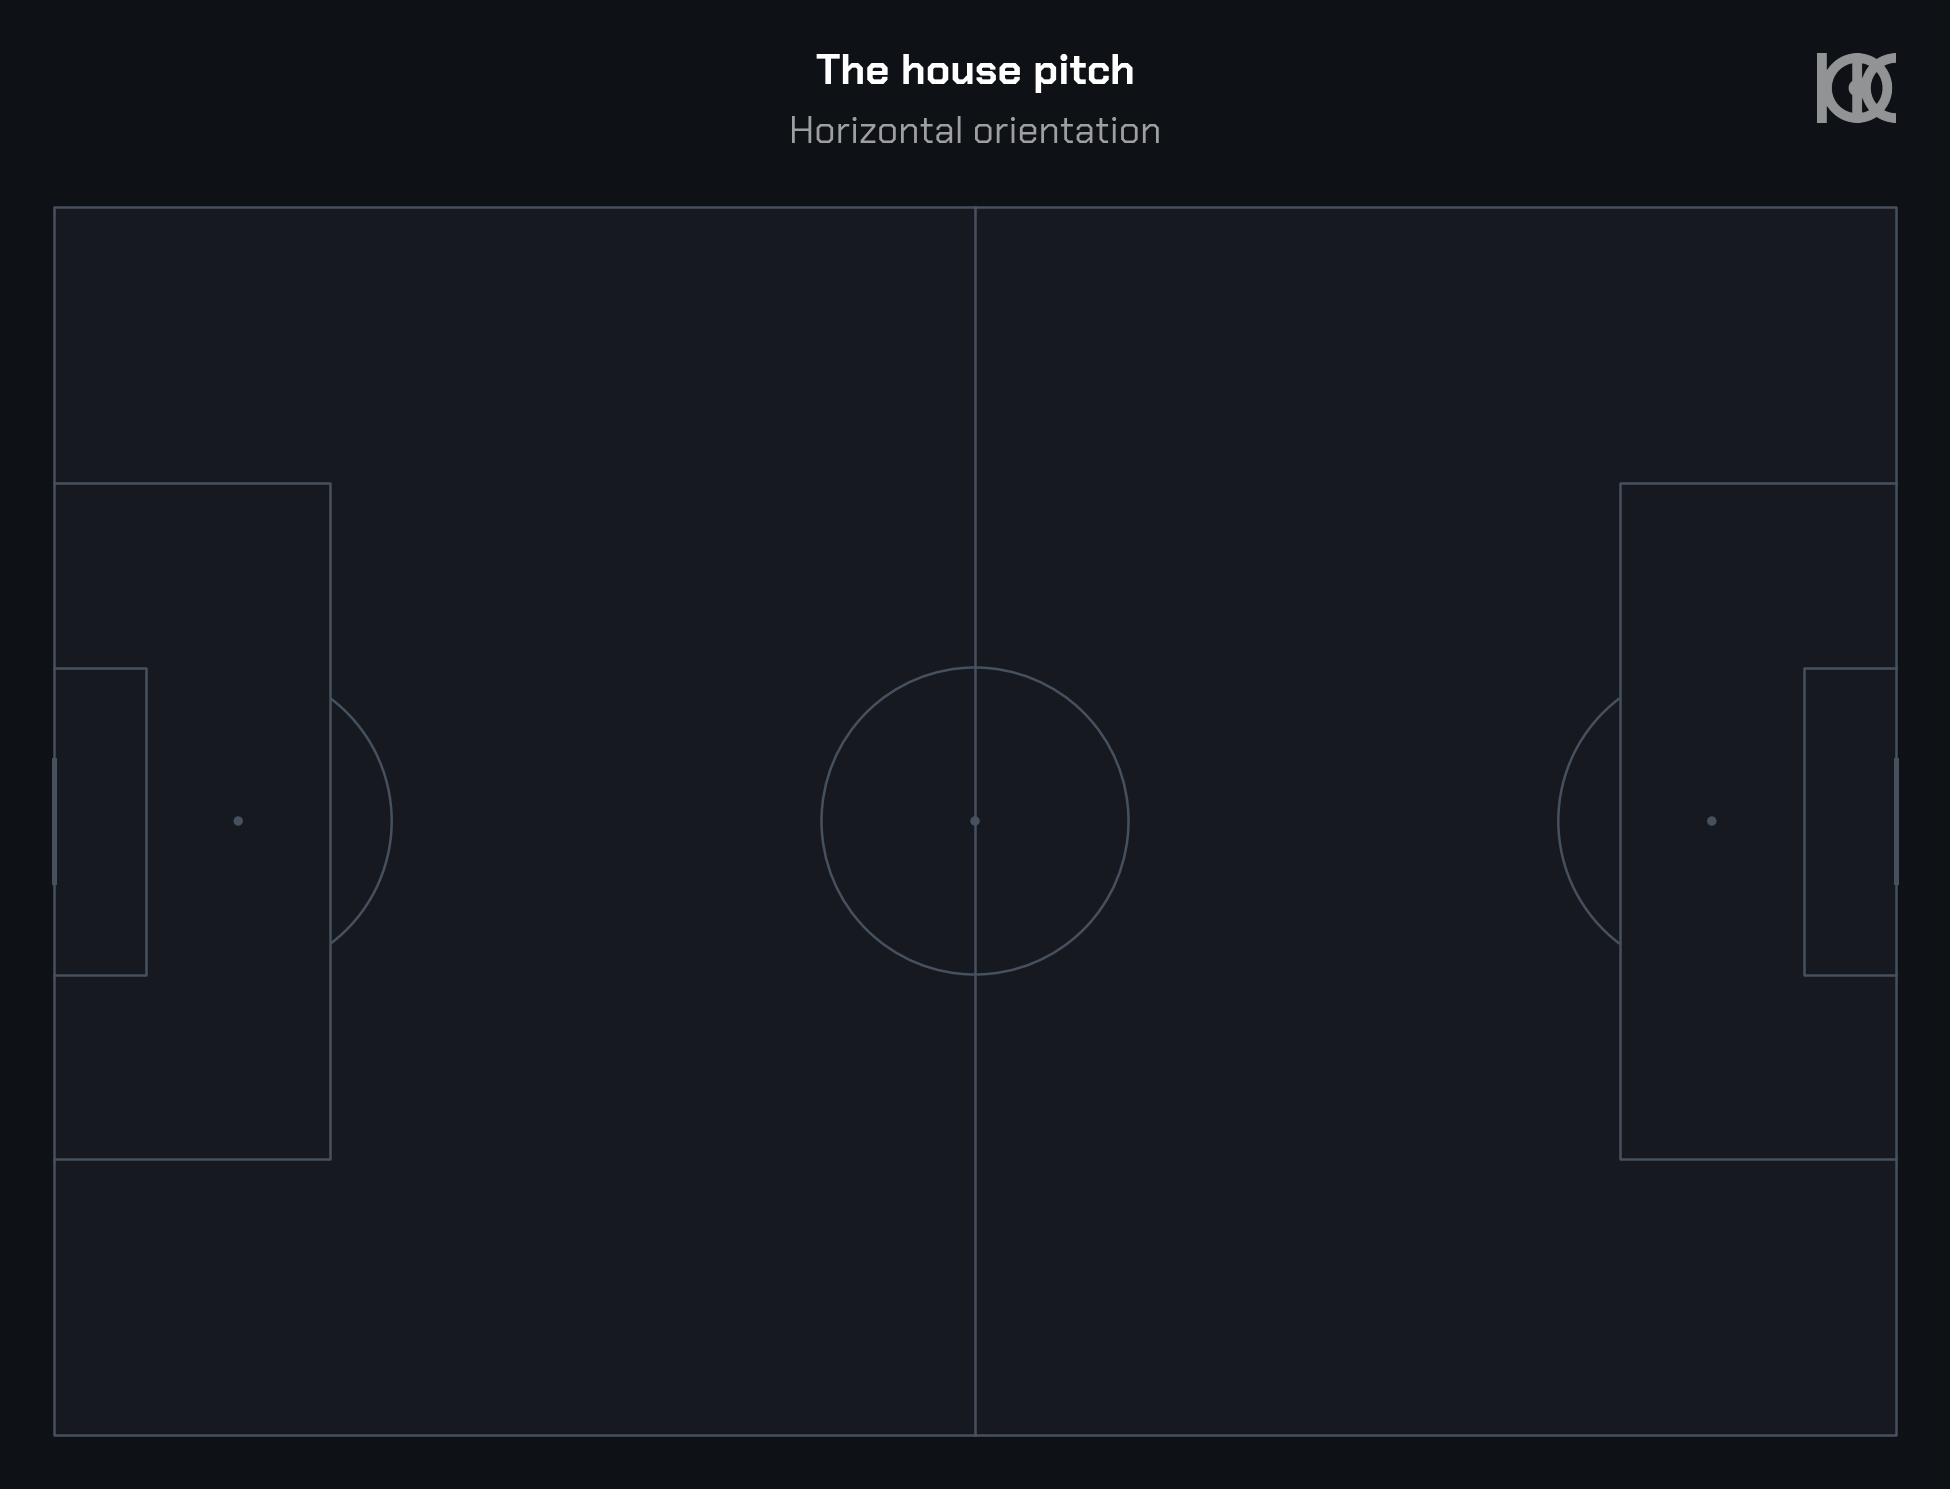

In [2]:
pitch, fig, ax = draw_kick_pitch()
kick_title(fig, ax, "The house pitch", "Horizontal orientation")
plt.show()

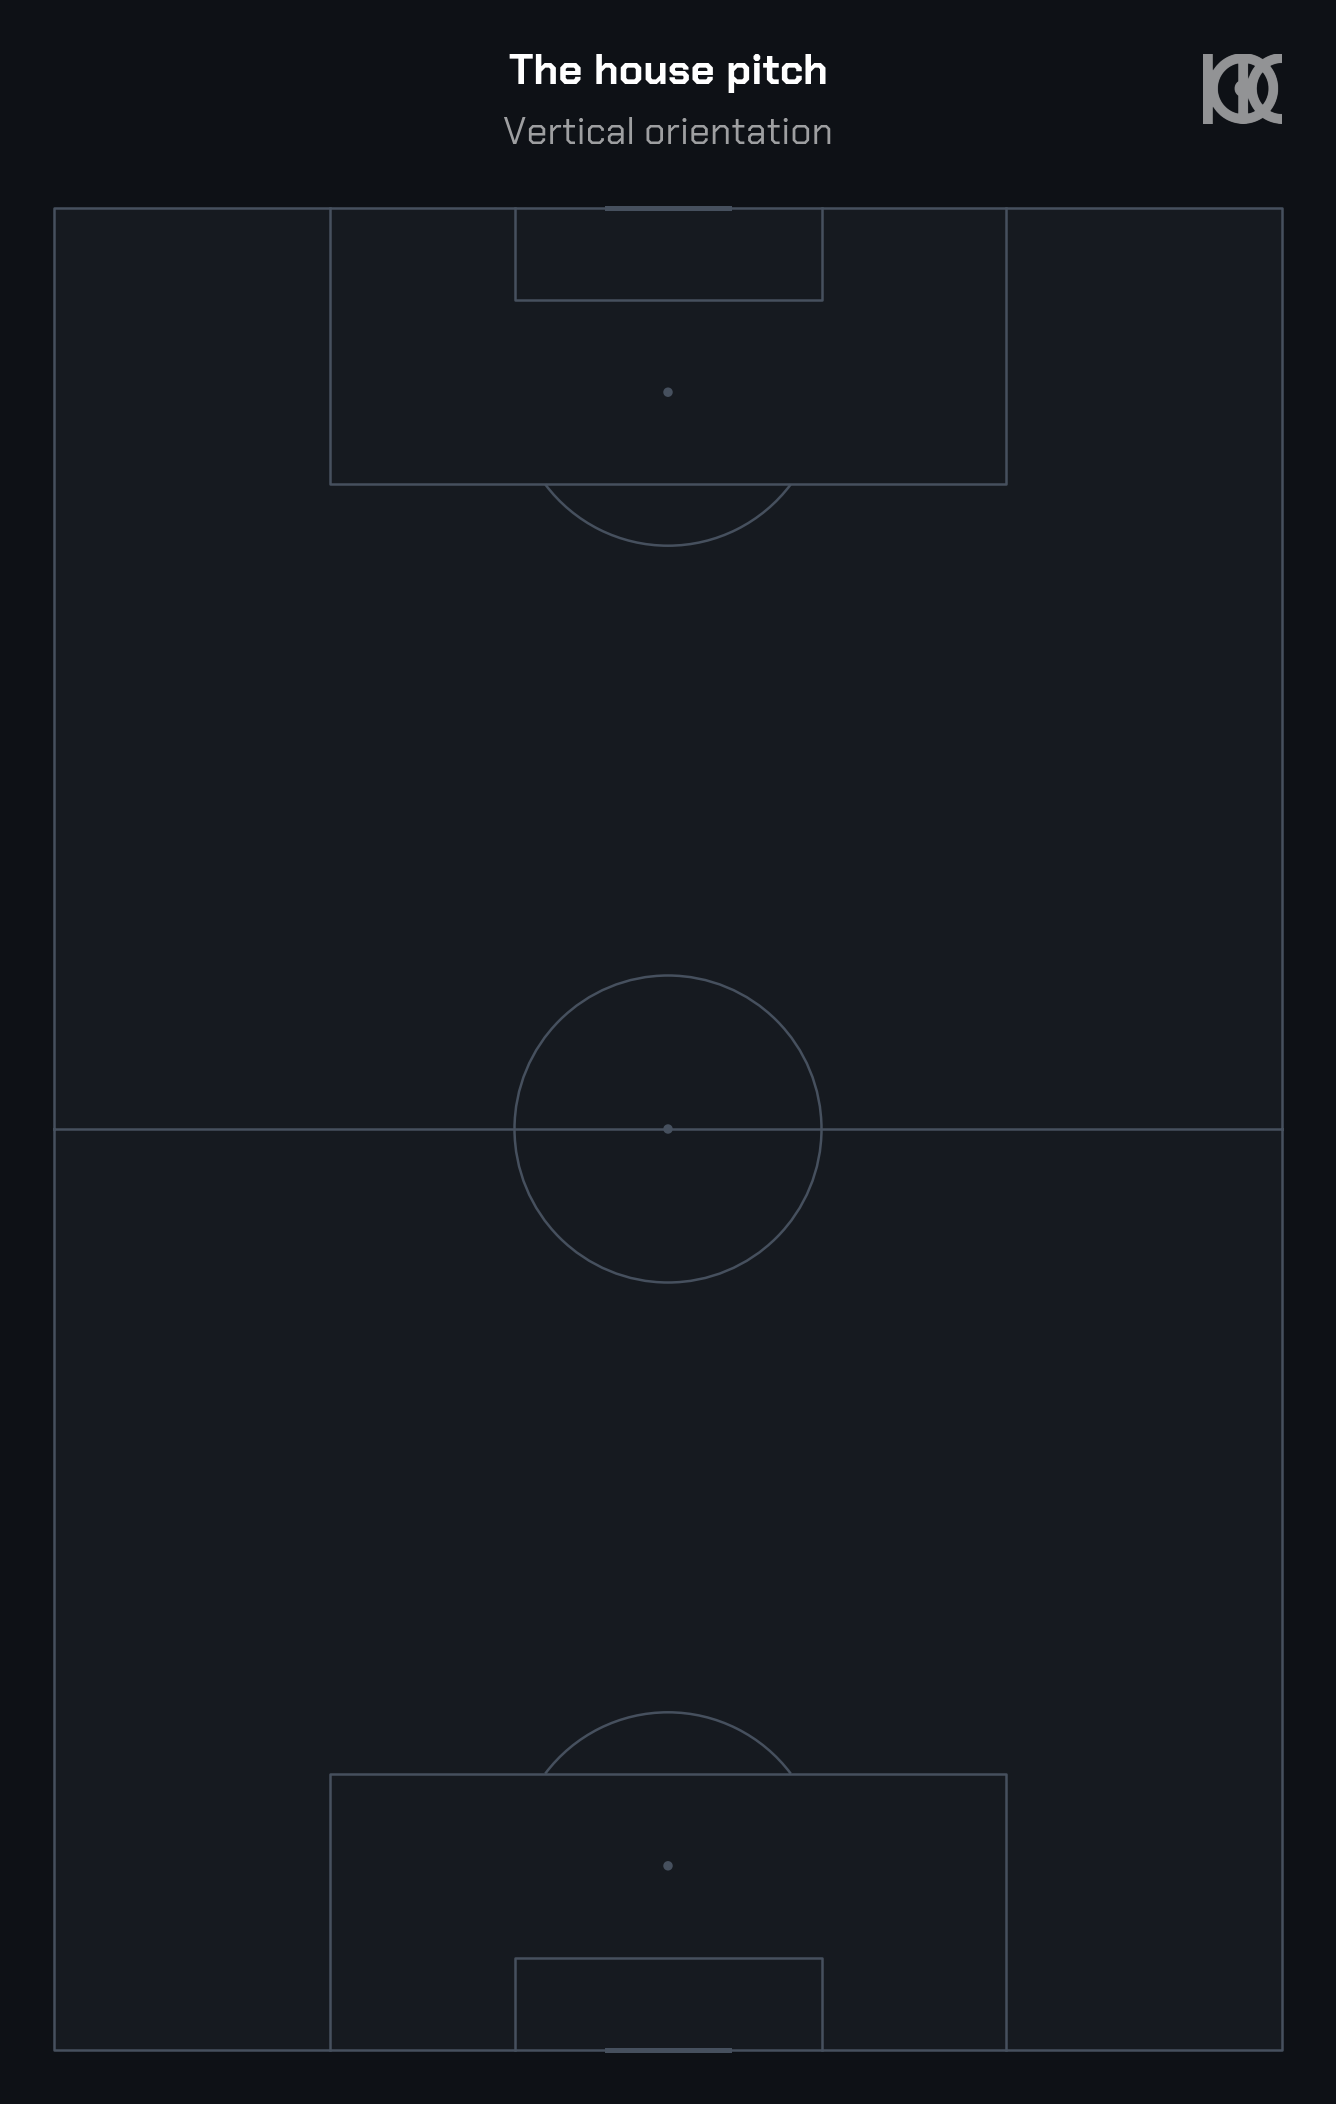

In [3]:
pitch, fig, ax = draw_kick_pitch(vertical=True)
kick_title(fig, ax, "The house pitch", "Vertical orientation")
plt.show()

**Matrix display.** `kick_grid(nrows, ncols, vertical=)` returns a grid of house pitches under one
overall header. Two everyday shapes: a **vertical 1×2** for A/B comparison (two halves, two teams,
before/after), and a **horizontal 3×3** for laying many states out at once (e.g. model-training
samples). Label each panel with `kick_panel_label`; the analytical form — a shared colourbar on a
common scale — is in §11.

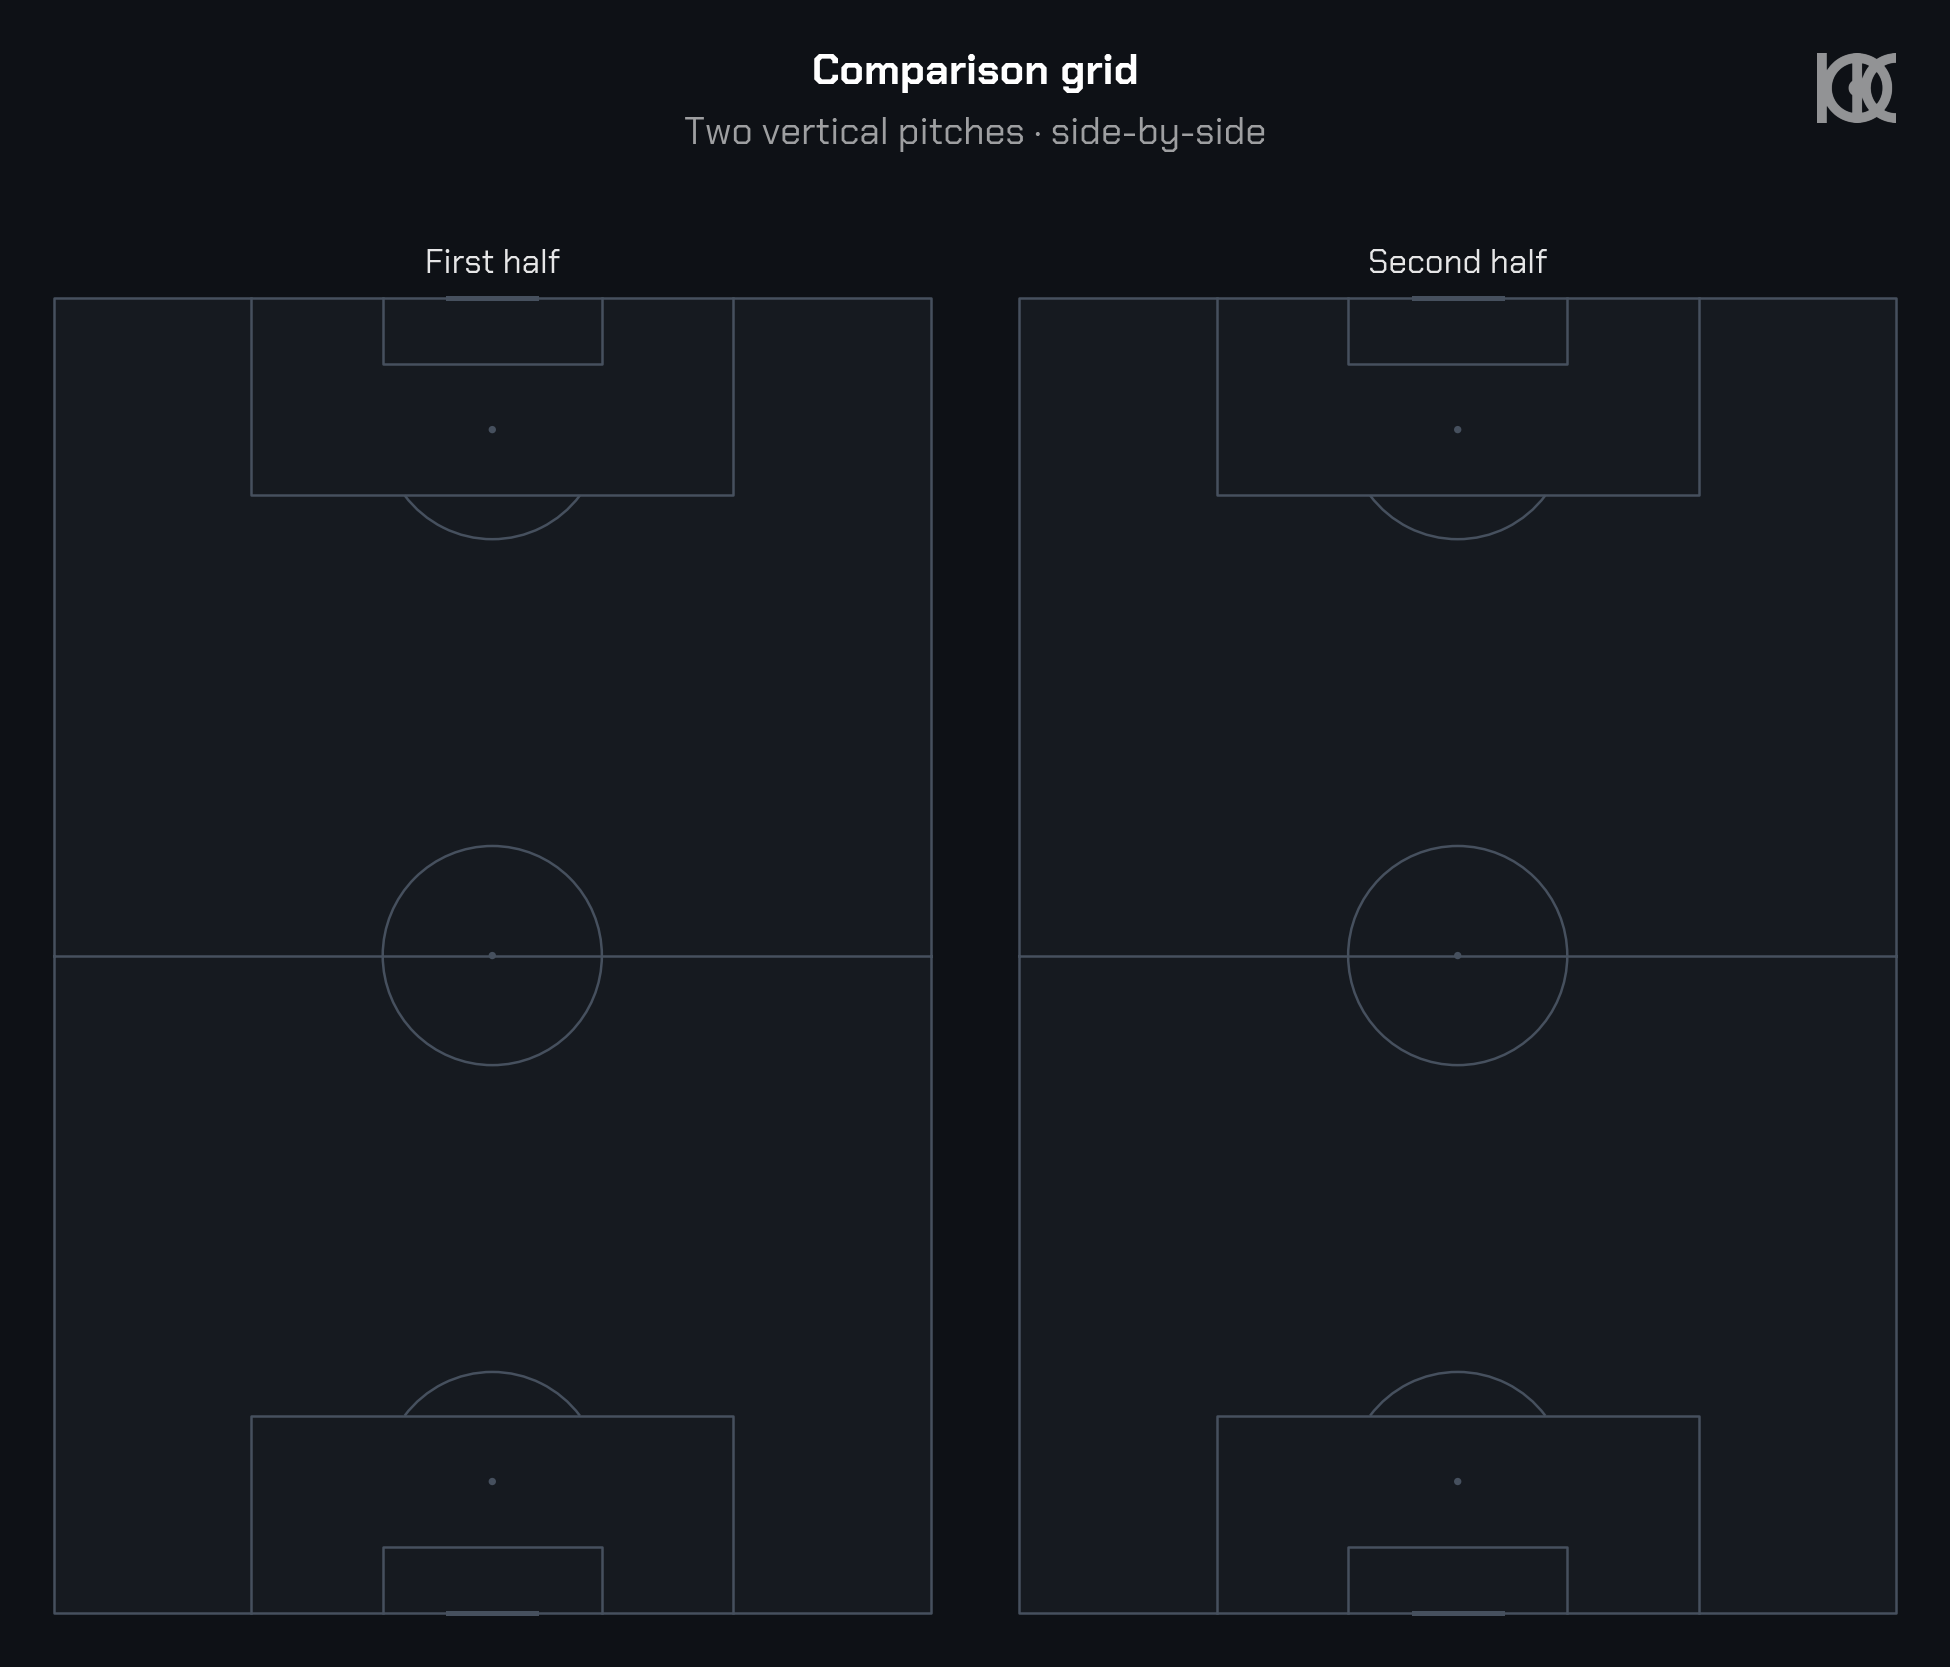

In [4]:
# vertical 1×2 — A/B comparison (empty canvases; content comes later)
pitch, fig, axes = kick_grid(1, 2, vertical=True)
for ax, lab in zip(axes.flat, ["First half", "Second half"]):
    kick_panel_label(ax, lab)
kick_grid_title(fig, axes, "Comparison grid", "Two vertical pitches · side-by-side")
plt.show()

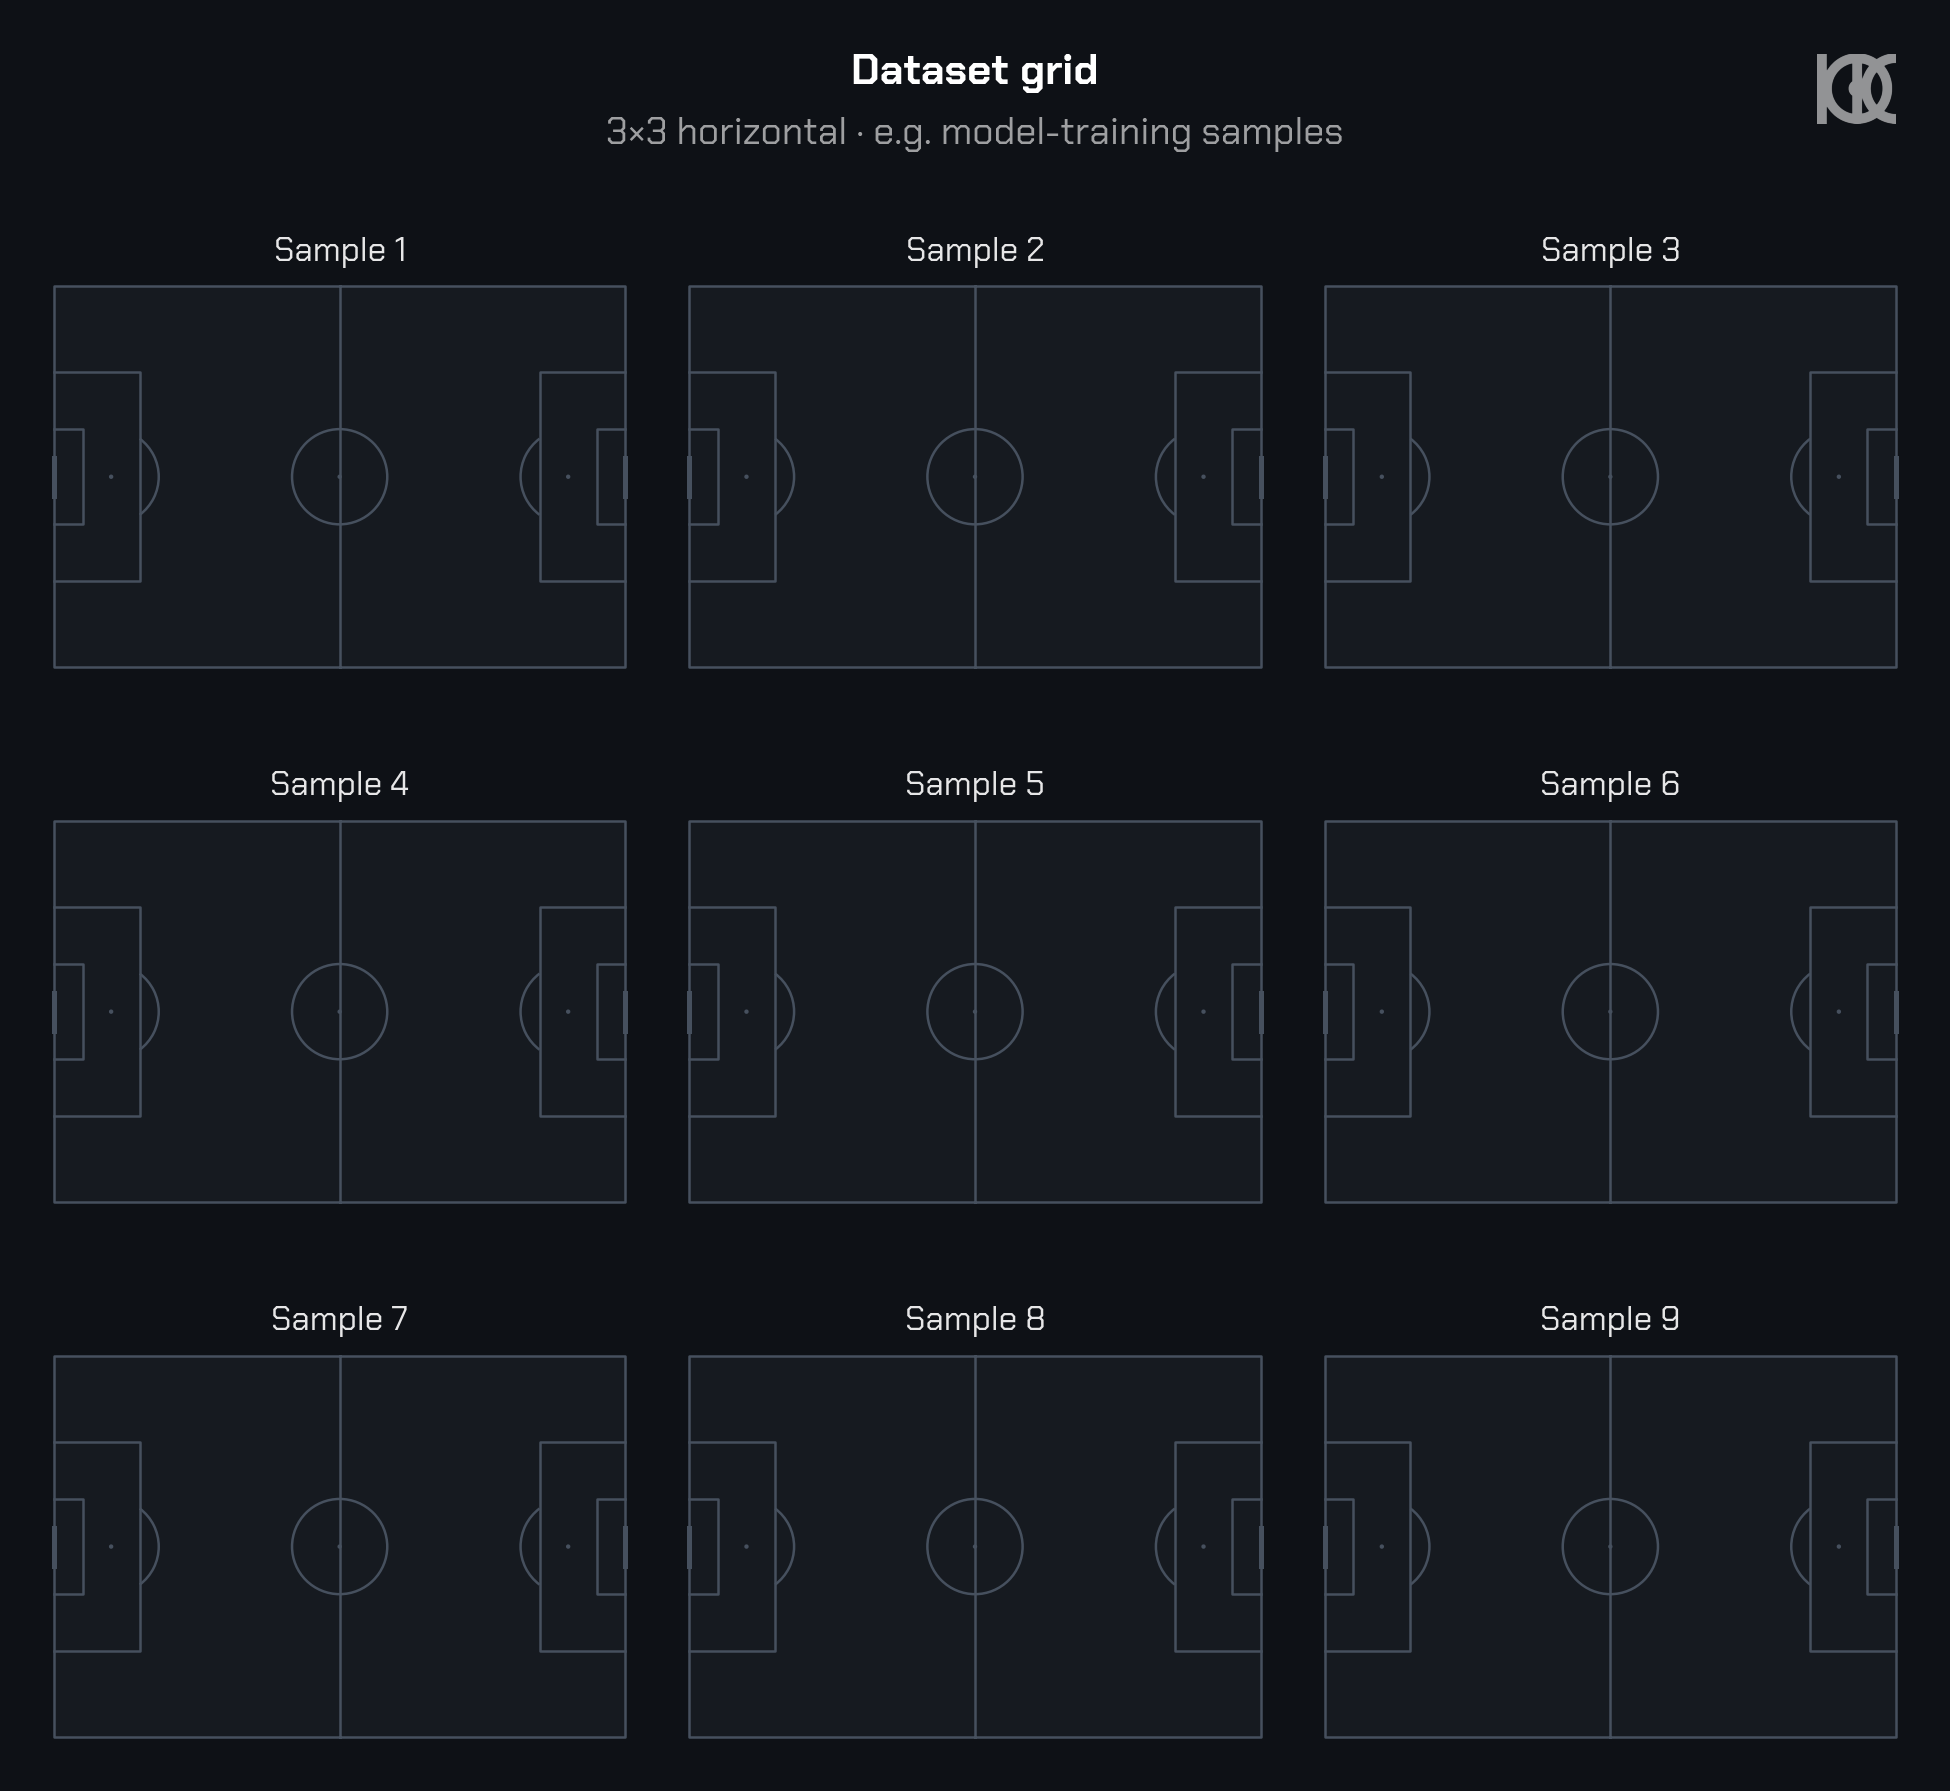

In [5]:
# horizontal 3×3 — a batch of pitches (e.g. model-training samples)
pitch, fig, axes = kick_grid(3, 3)
for i, ax in enumerate(axes.flat):
    kick_panel_label(ax, f"Sample {i+1}")
kick_grid_title(fig, axes, "Dataset grid", "3×3 horizontal · e.g. model-training samples")
plt.show()

## 3 · Team scatter — *categorical / identity*

Home orange, away **white**, ball a **hi-vis yellow** dot at **half the player diameter** (distinct from
both teams by colour *and* size). `kick_legend()` drops the legend into the bottom band (which widens only
when a legend is present). Vertical variant below.

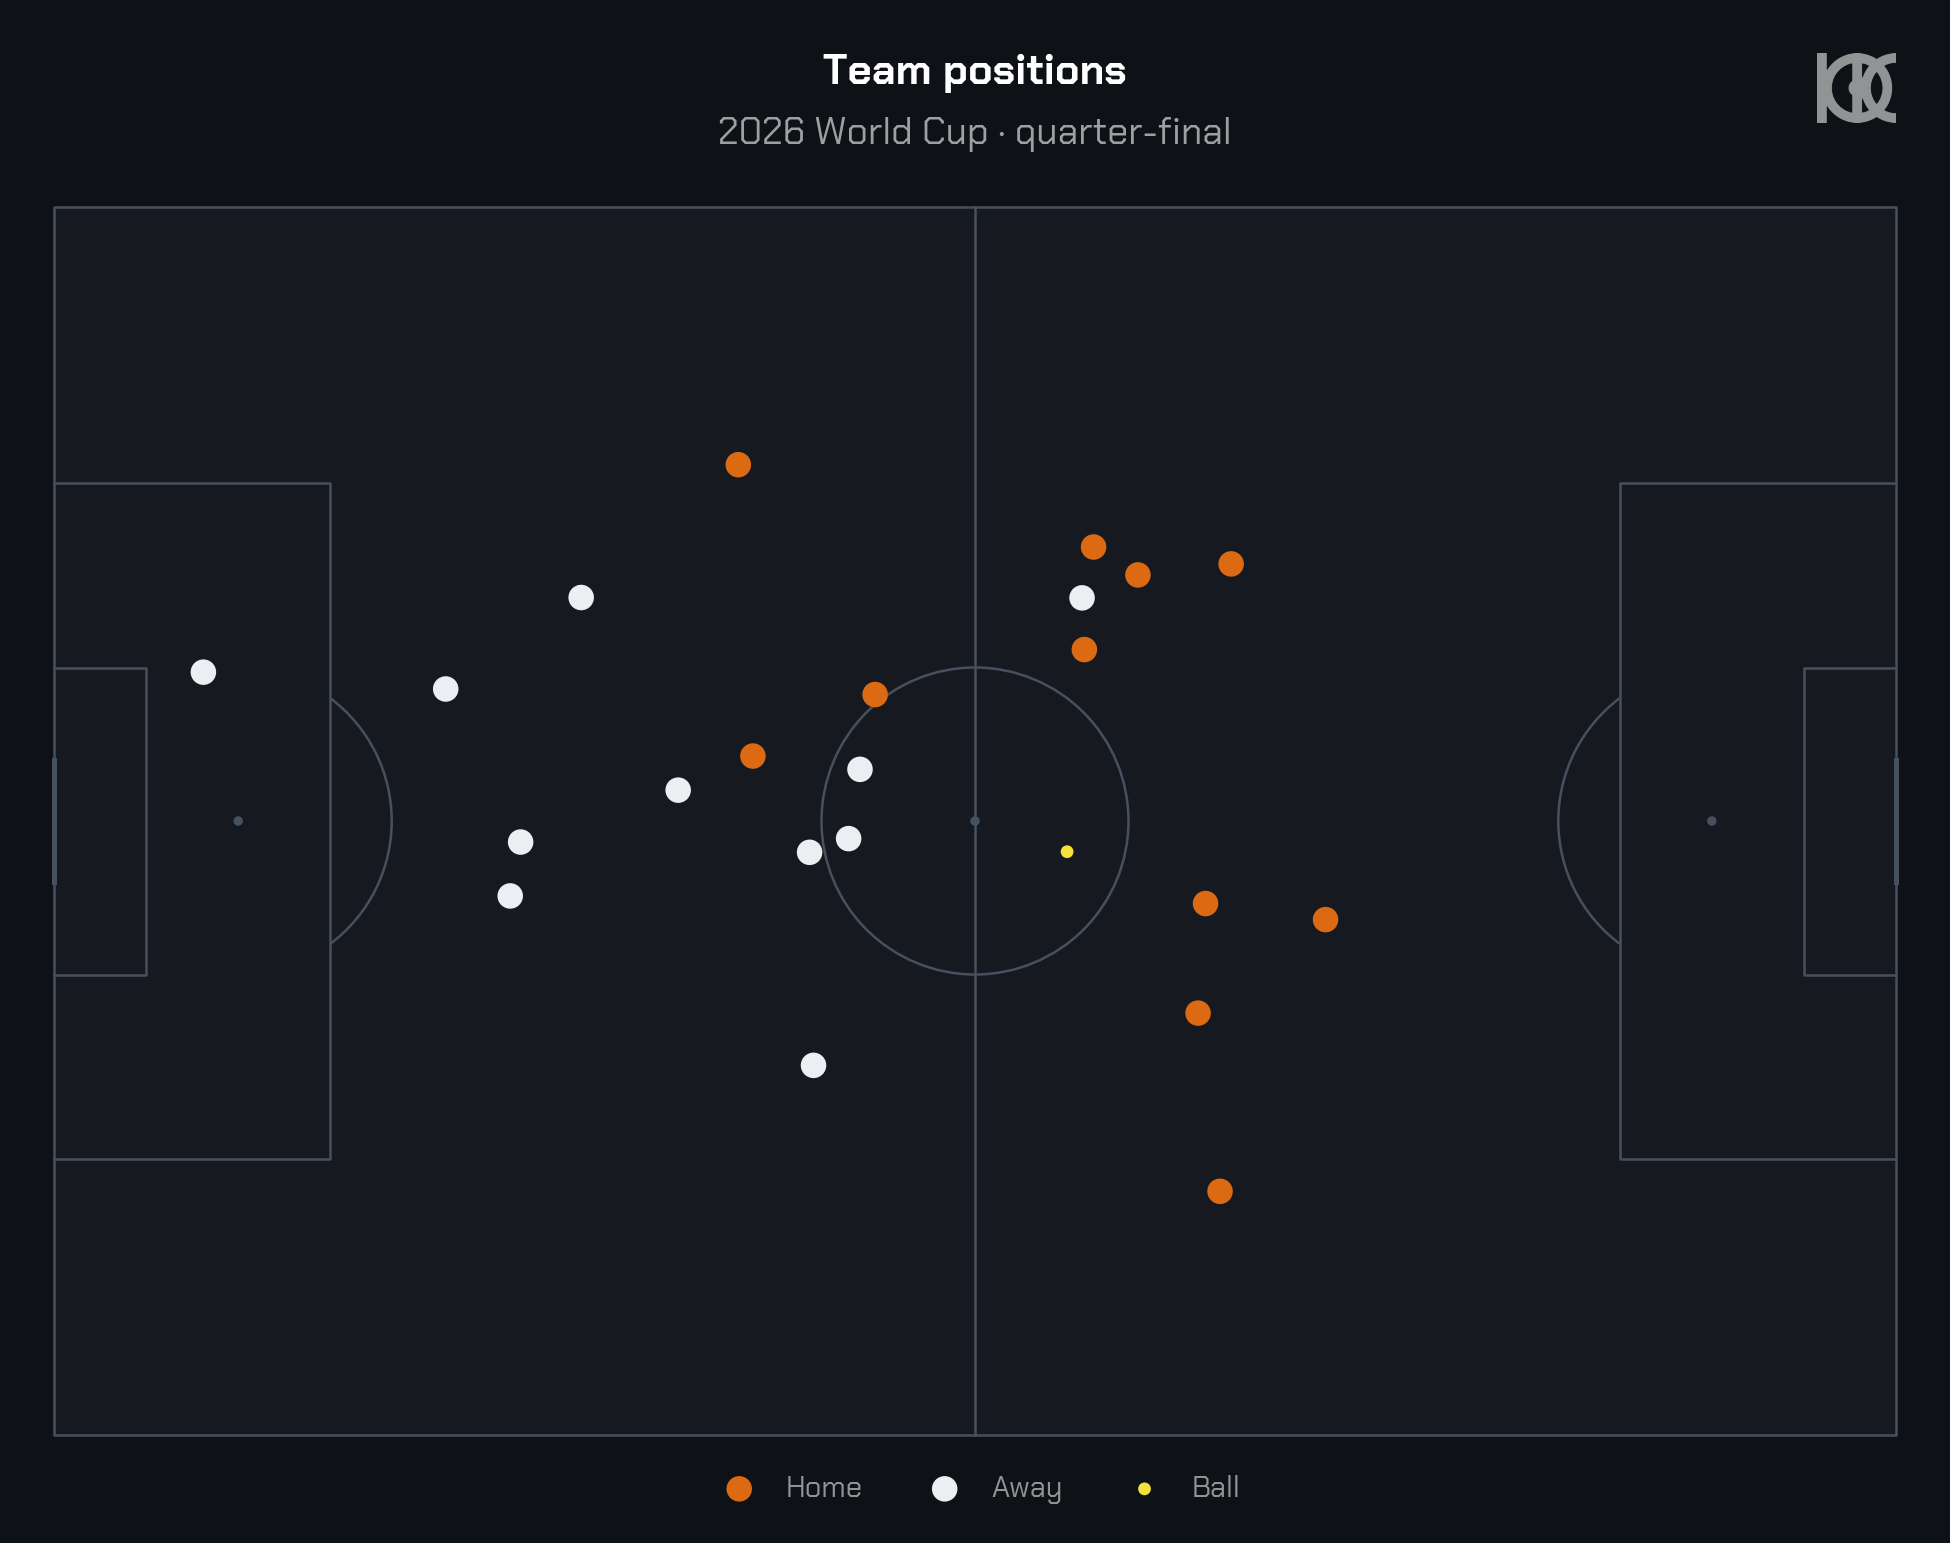

In [6]:
rng = np.random.default_rng(7)
home_xy = rng.normal([75, 40], [16, 18], (11, 2)).clip([1, 1], [119, 79])
away_xy = rng.normal([50, 40], [16, 18], (11, 2)).clip([1, 1], [119, 79])
pitch, fig, ax = draw_kick_pitch(vertical=False, legend=True)
for xy, key, lab in [(home_xy, "home", "Home"), (away_xy, "away", "Away")]:
    pitch.scatter(xy[:, 0], xy[:, 1], s=150, color=KICK[key], edgecolors="none",   # no outline — dots pop on dark
                  zorder=4, ax=ax, label=lab)
pitch.scatter(66, 42, s=150 * 0.25, color=KICK["ball"], edgecolors="none",         # hi-vis yellow, half player Ø
              zorder=5, ax=ax, label="Ball")
kick_legend(fig, ax)
kick_title(fig, ax, "Team positions", "2026 World Cup · quarter-final")
plt.show()

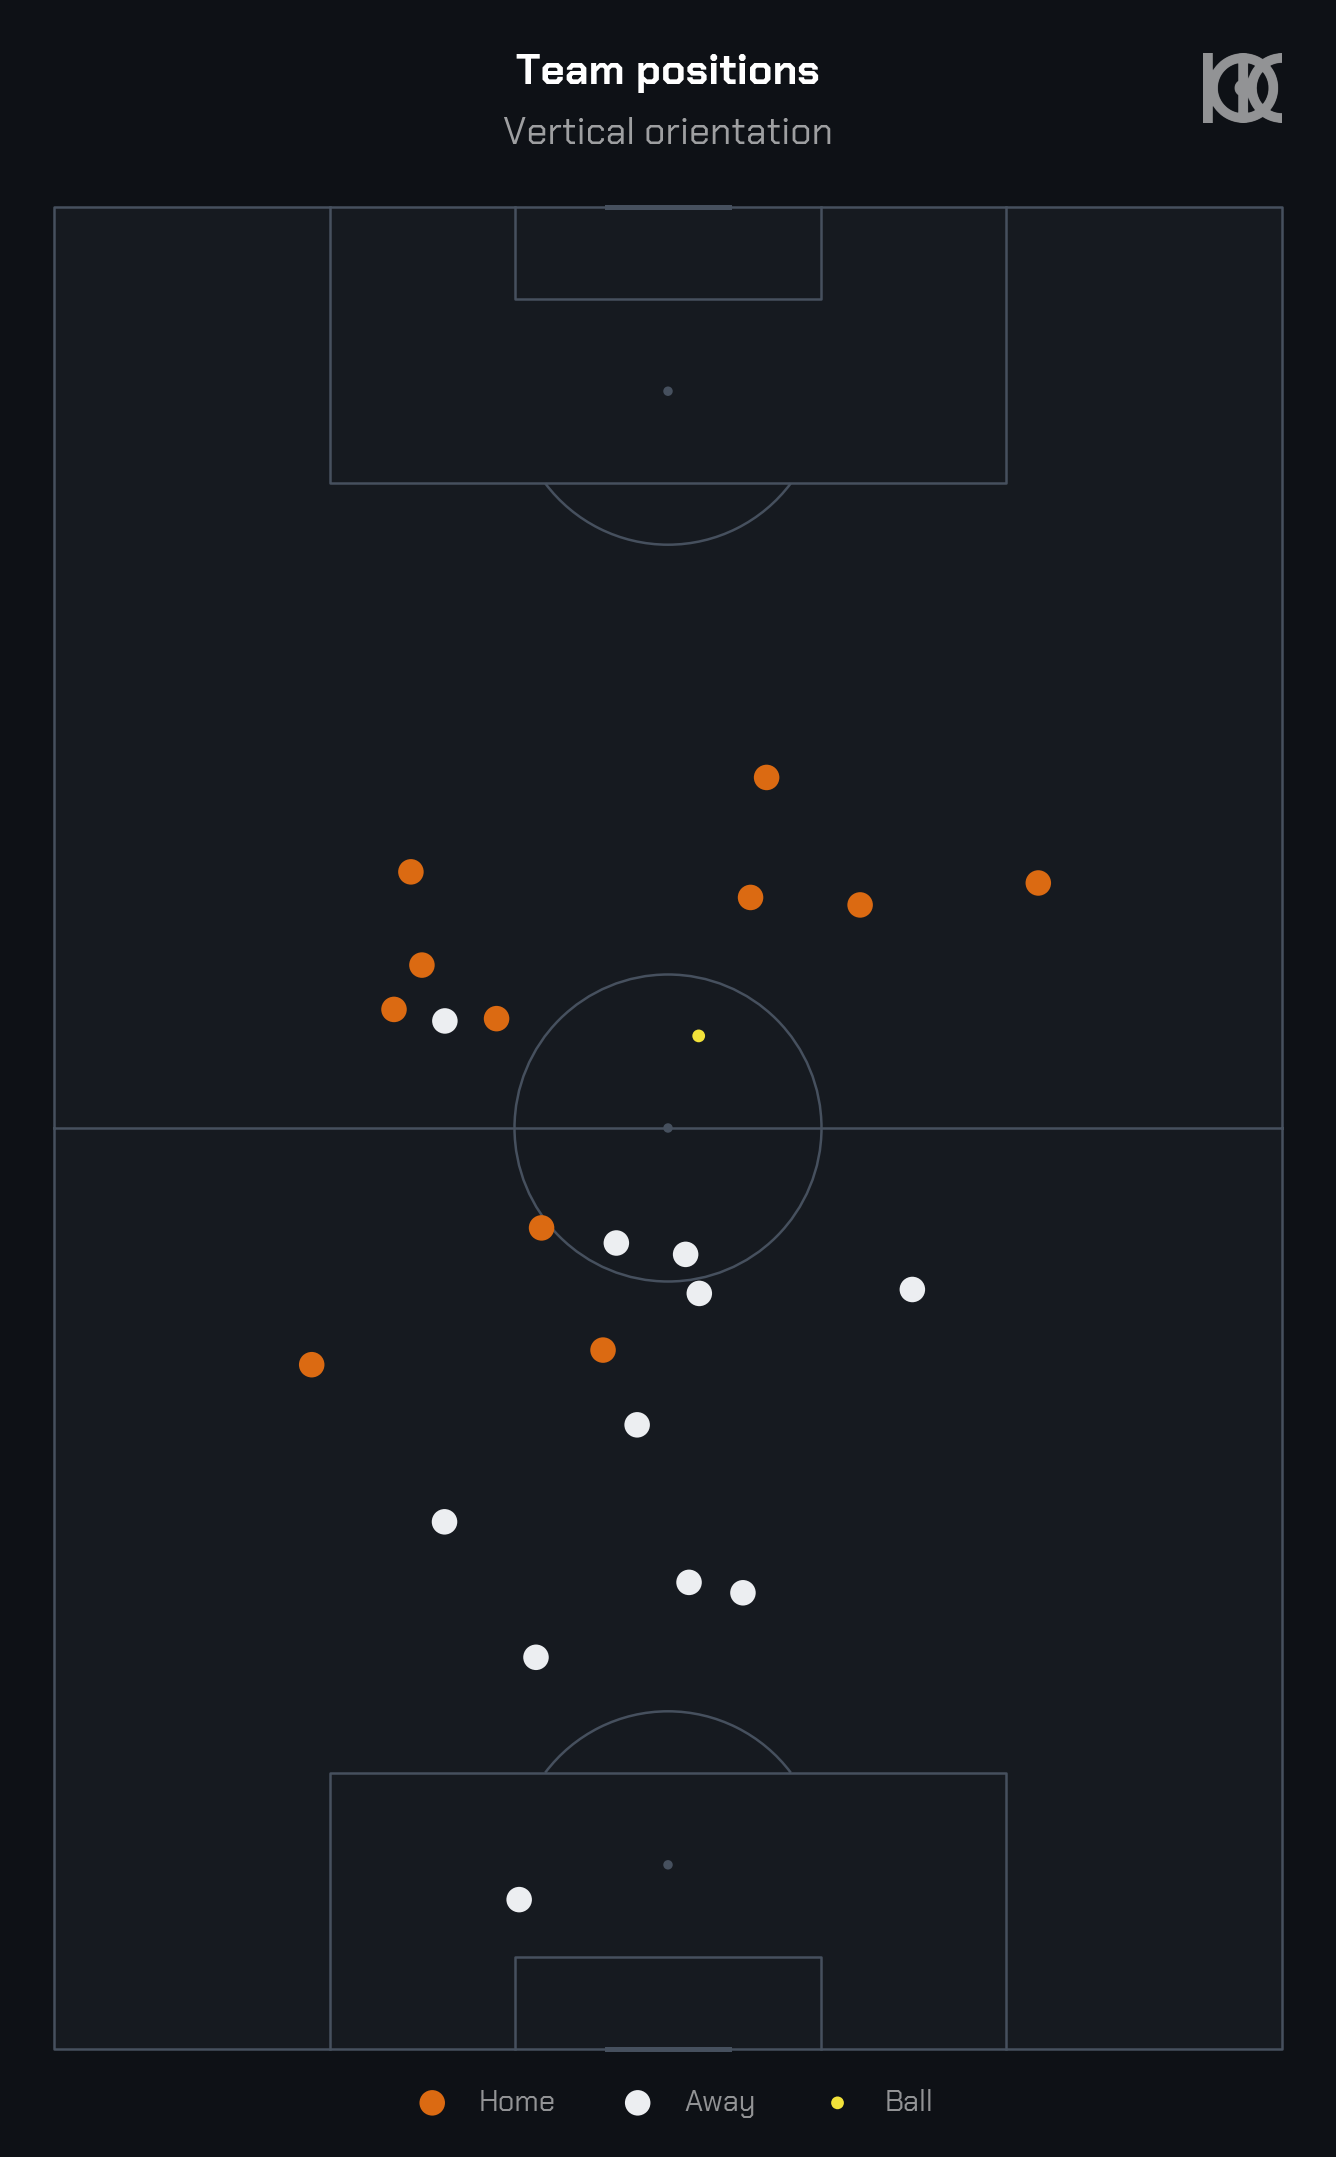

In [7]:
rng = np.random.default_rng(7)
home_xy = rng.normal([75, 40], [16, 18], (11, 2)).clip([1, 1], [119, 79])
away_xy = rng.normal([50, 40], [16, 18], (11, 2)).clip([1, 1], [119, 79])
pitch, fig, ax = draw_kick_pitch(vertical=True, legend=True)
for xy, key, lab in [(home_xy, "home", "Home"), (away_xy, "away", "Away")]:
    pitch.scatter(xy[:, 0], xy[:, 1], s=150, color=KICK[key], edgecolors="none",   # no outline — dots pop on dark
                  zorder=4, ax=ax, label=lab)
pitch.scatter(66, 42, s=150 * 0.25, color=KICK["ball"], edgecolors="none",         # hi-vis yellow, half player Ø
              zorder=5, ax=ax, label="Ball")
kick_legend(fig, ax)
kick_title(fig, ax, "Team positions", "Vertical orientation")
plt.show()

## 4 · Threat / xT surface — *grid heatmap (sequential)*

Gridded magnitude (xT is literally a grid) → **`kick_heatmap`** with `KICK_SEQ`, the **ice-glow** ramp:
its dark end *is* the pitch tone, so low values melt into the pitch and threat **glows out of it** (cool
white, rising to a white-hot core). Cells abut with no separators so the surface reads as one field. The
colourbar sits in a band **below the pitch** (horizontal) via `kick_cbar()` — `cbar_pos="right"` puts it
in a right gutter instead.

The grid resolution is a **parameter, not a baked-in constant**: `threat_grid(nx, ny)` builds the same
surface at any cell count, and the 2×2 below (the §2 small-multiples grid) compares coarse → fine.

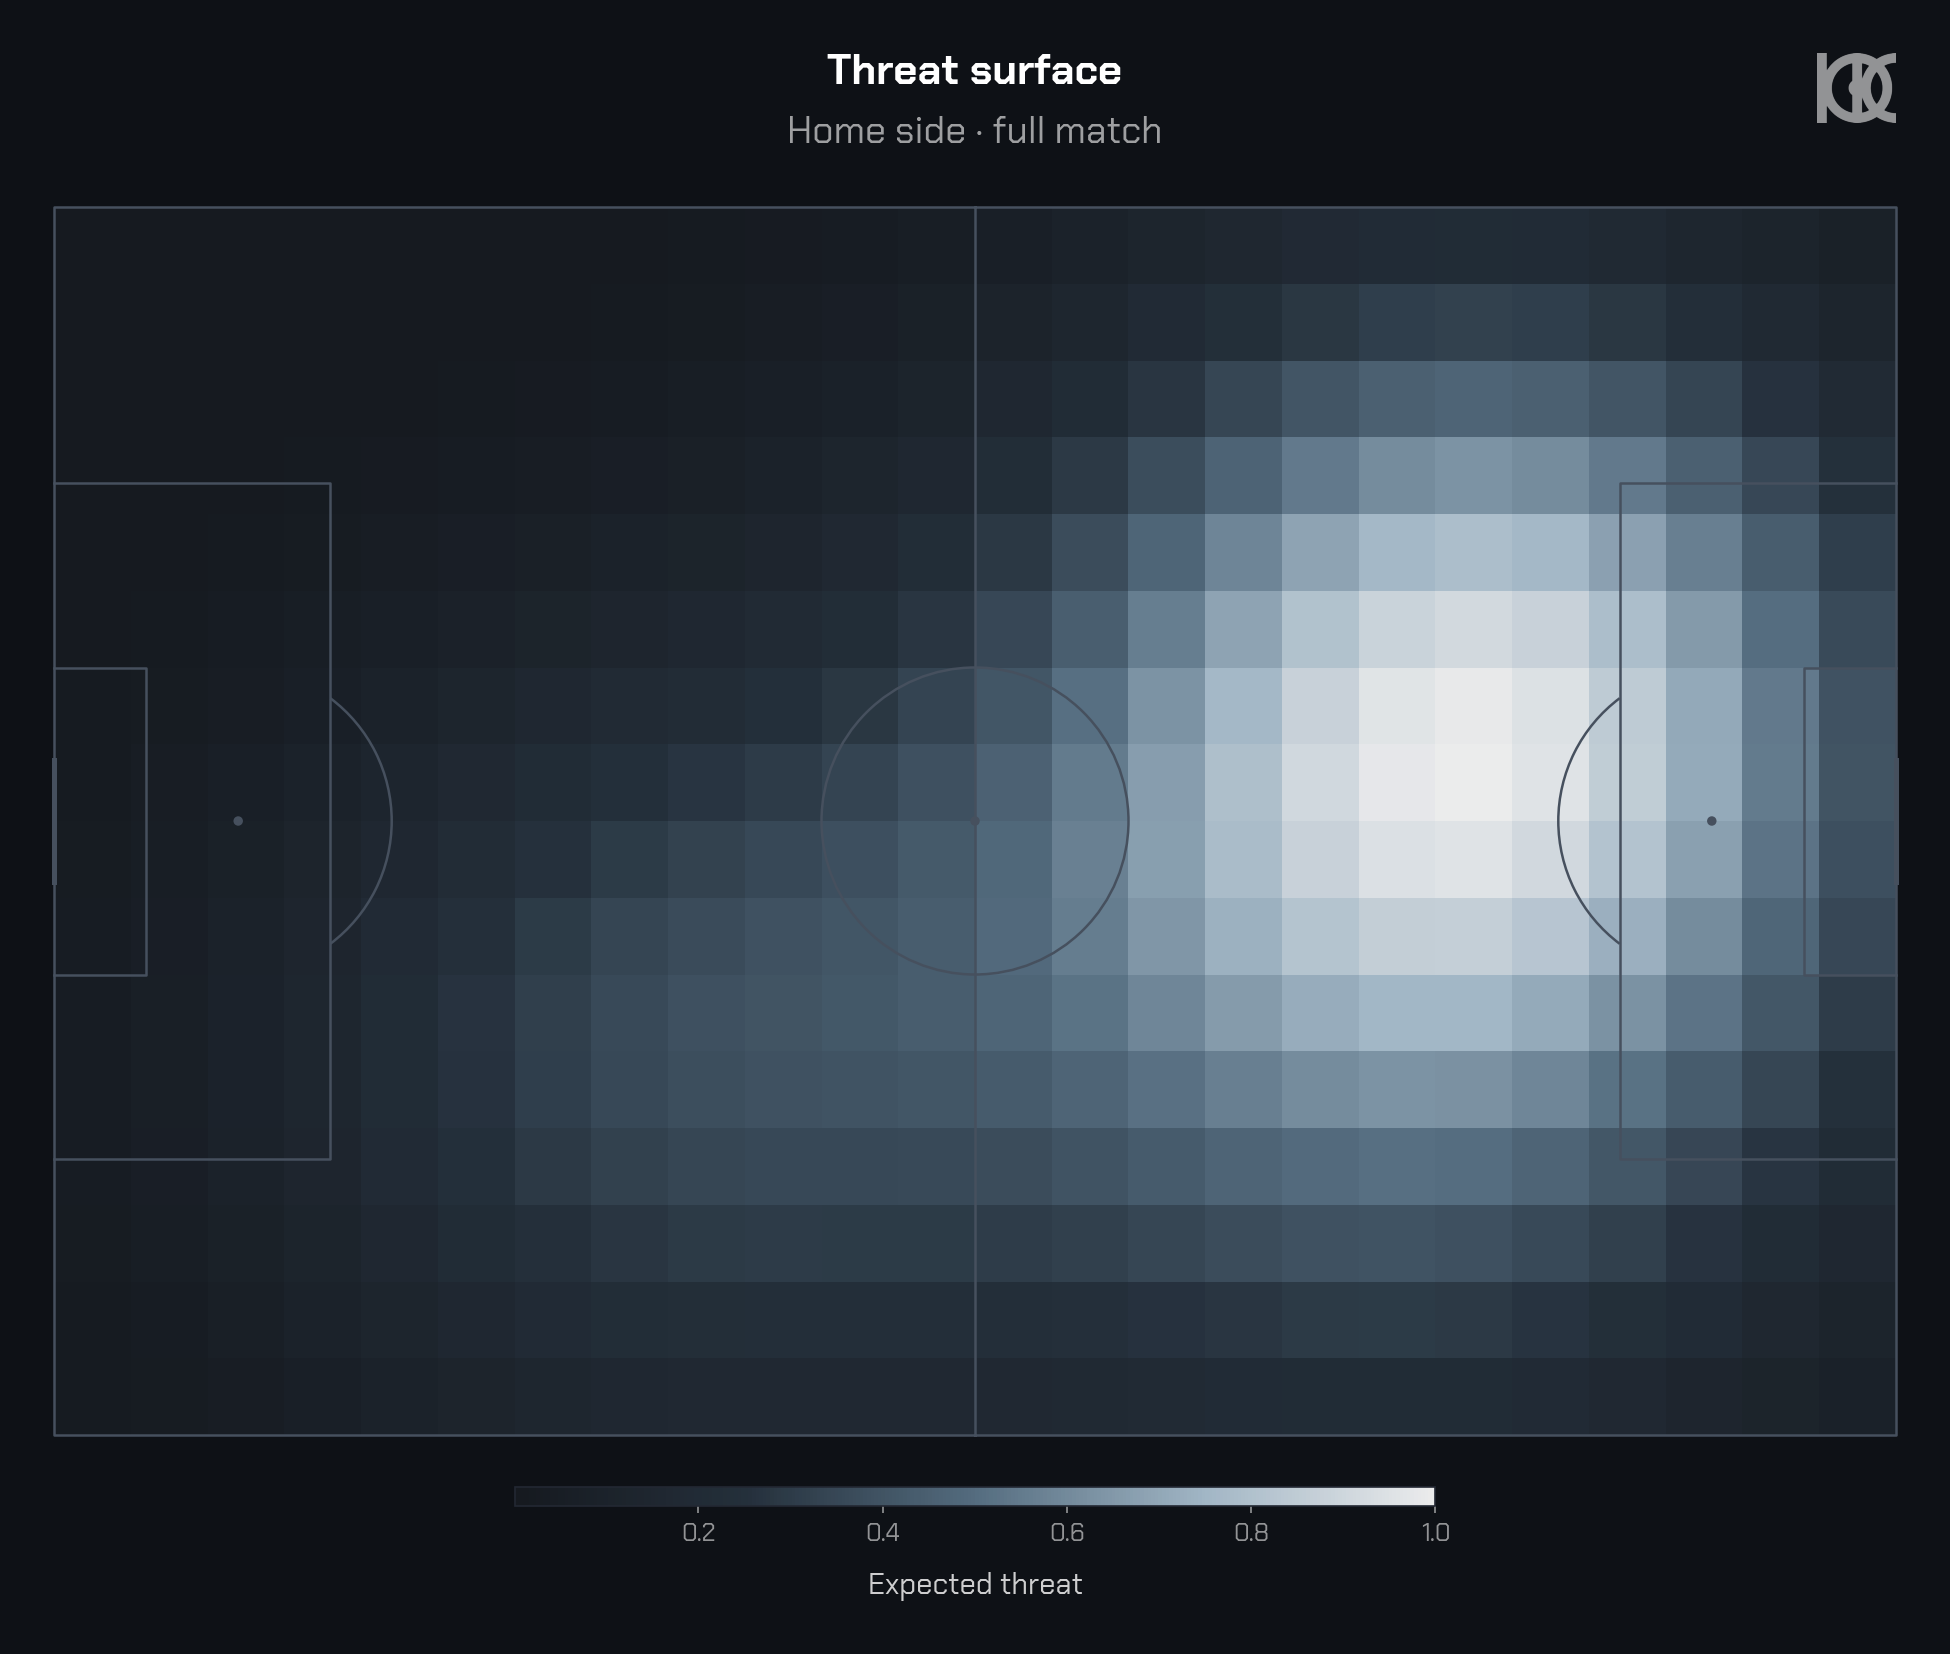

In [8]:
def blob(gx, gy, spots):
    z = np.zeros_like(gx)
    for (mx, my, s, a) in spots:
        z += a * np.exp(-(((gx - mx) ** 2) / (2 * s ** 2) + ((gy - my) ** 2) / (2 * s ** 2)))
    return z / np.abs(z).max()

SPOTS = [(88, 44, 22, 1.0), (95, 30, 16, 0.7), (40, 55, 18, 0.5)]

def threat_grid(nx, ny):
    """Cell edges + normalized threat for an nx × ny grid — resolution is a free parameter."""
    xe = np.linspace(0, 120, nx + 1); ye = np.linspace(0, 80, ny + 1)
    gx, gy = np.meshgrid((xe[:-1] + xe[1:]) / 2, (ye[:-1] + ye[1:]) / 2)
    return xe, ye, blob(gx, gy, SPOTS)

xe, ye, z = threat_grid(24, 16)
pitch, fig, ax = draw_kick_pitch(line_zorder=3, cbar=True)
m = kick_heatmap(ax, xe, ye, z)
kick_cbar(fig, ax, m, "Expected threat")
kick_title(fig, ax, "Threat surface", "Home side · full match")
plt.show()

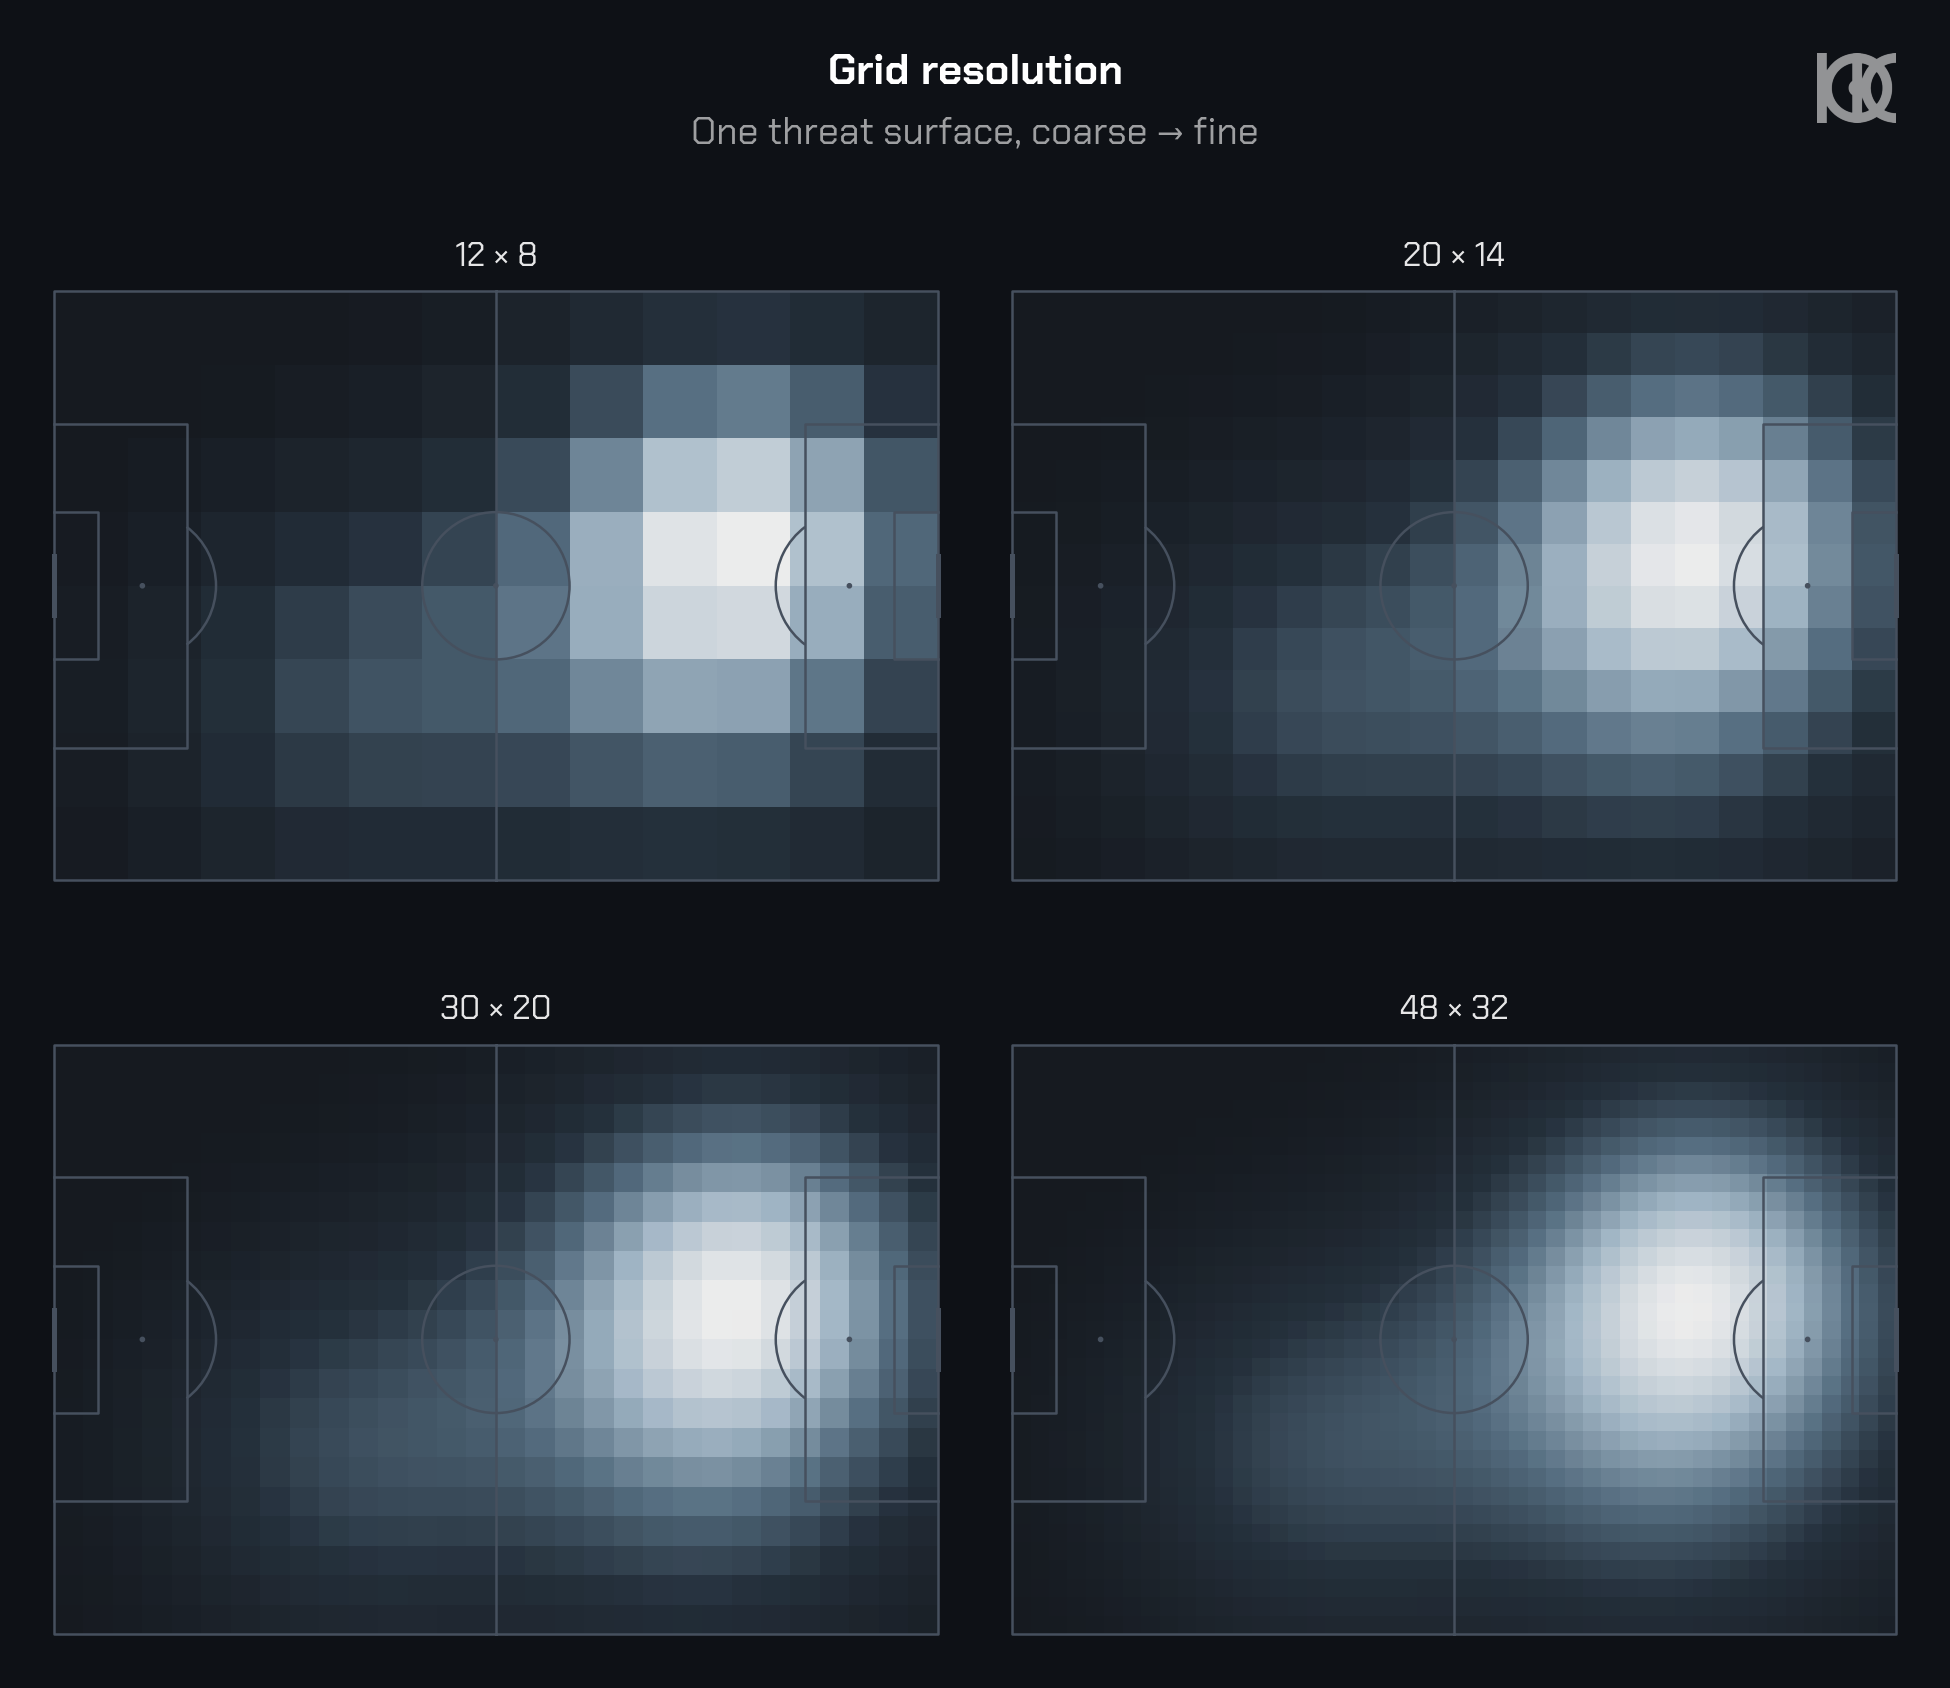

In [9]:
# resolution is a knob — the same surface at four cell counts (reuses the §2 small-multiples grid)
resolutions = [(12, 8), (20, 14), (30, 20), (48, 32)]
pitch, fig, axes = kick_grid(2, 2, line_zorder=3)
for ax, (nx, ny) in zip(axes.flat, resolutions):
    xe, ye, z = threat_grid(nx, ny)
    kick_heatmap(ax, xe, ye, z)
    kick_panel_label(ax, f"{nx} × {ny}")
kick_grid_title(fig, axes, "Grid resolution", "One threat surface, coarse → fine")
plt.show()

## 5 · Pitch control — *contour map (diverging)*

Continuous, signed field (who controls the space) → **`kick_contour`** with the diverging map:
away-blue ↔ neutral (recedes into the pitch) ↔ home-red. Symmetric levels around zero. The **band
count** is a parameter, like grid resolution — the 2×2 shows few → many layers (blocky → smooth).

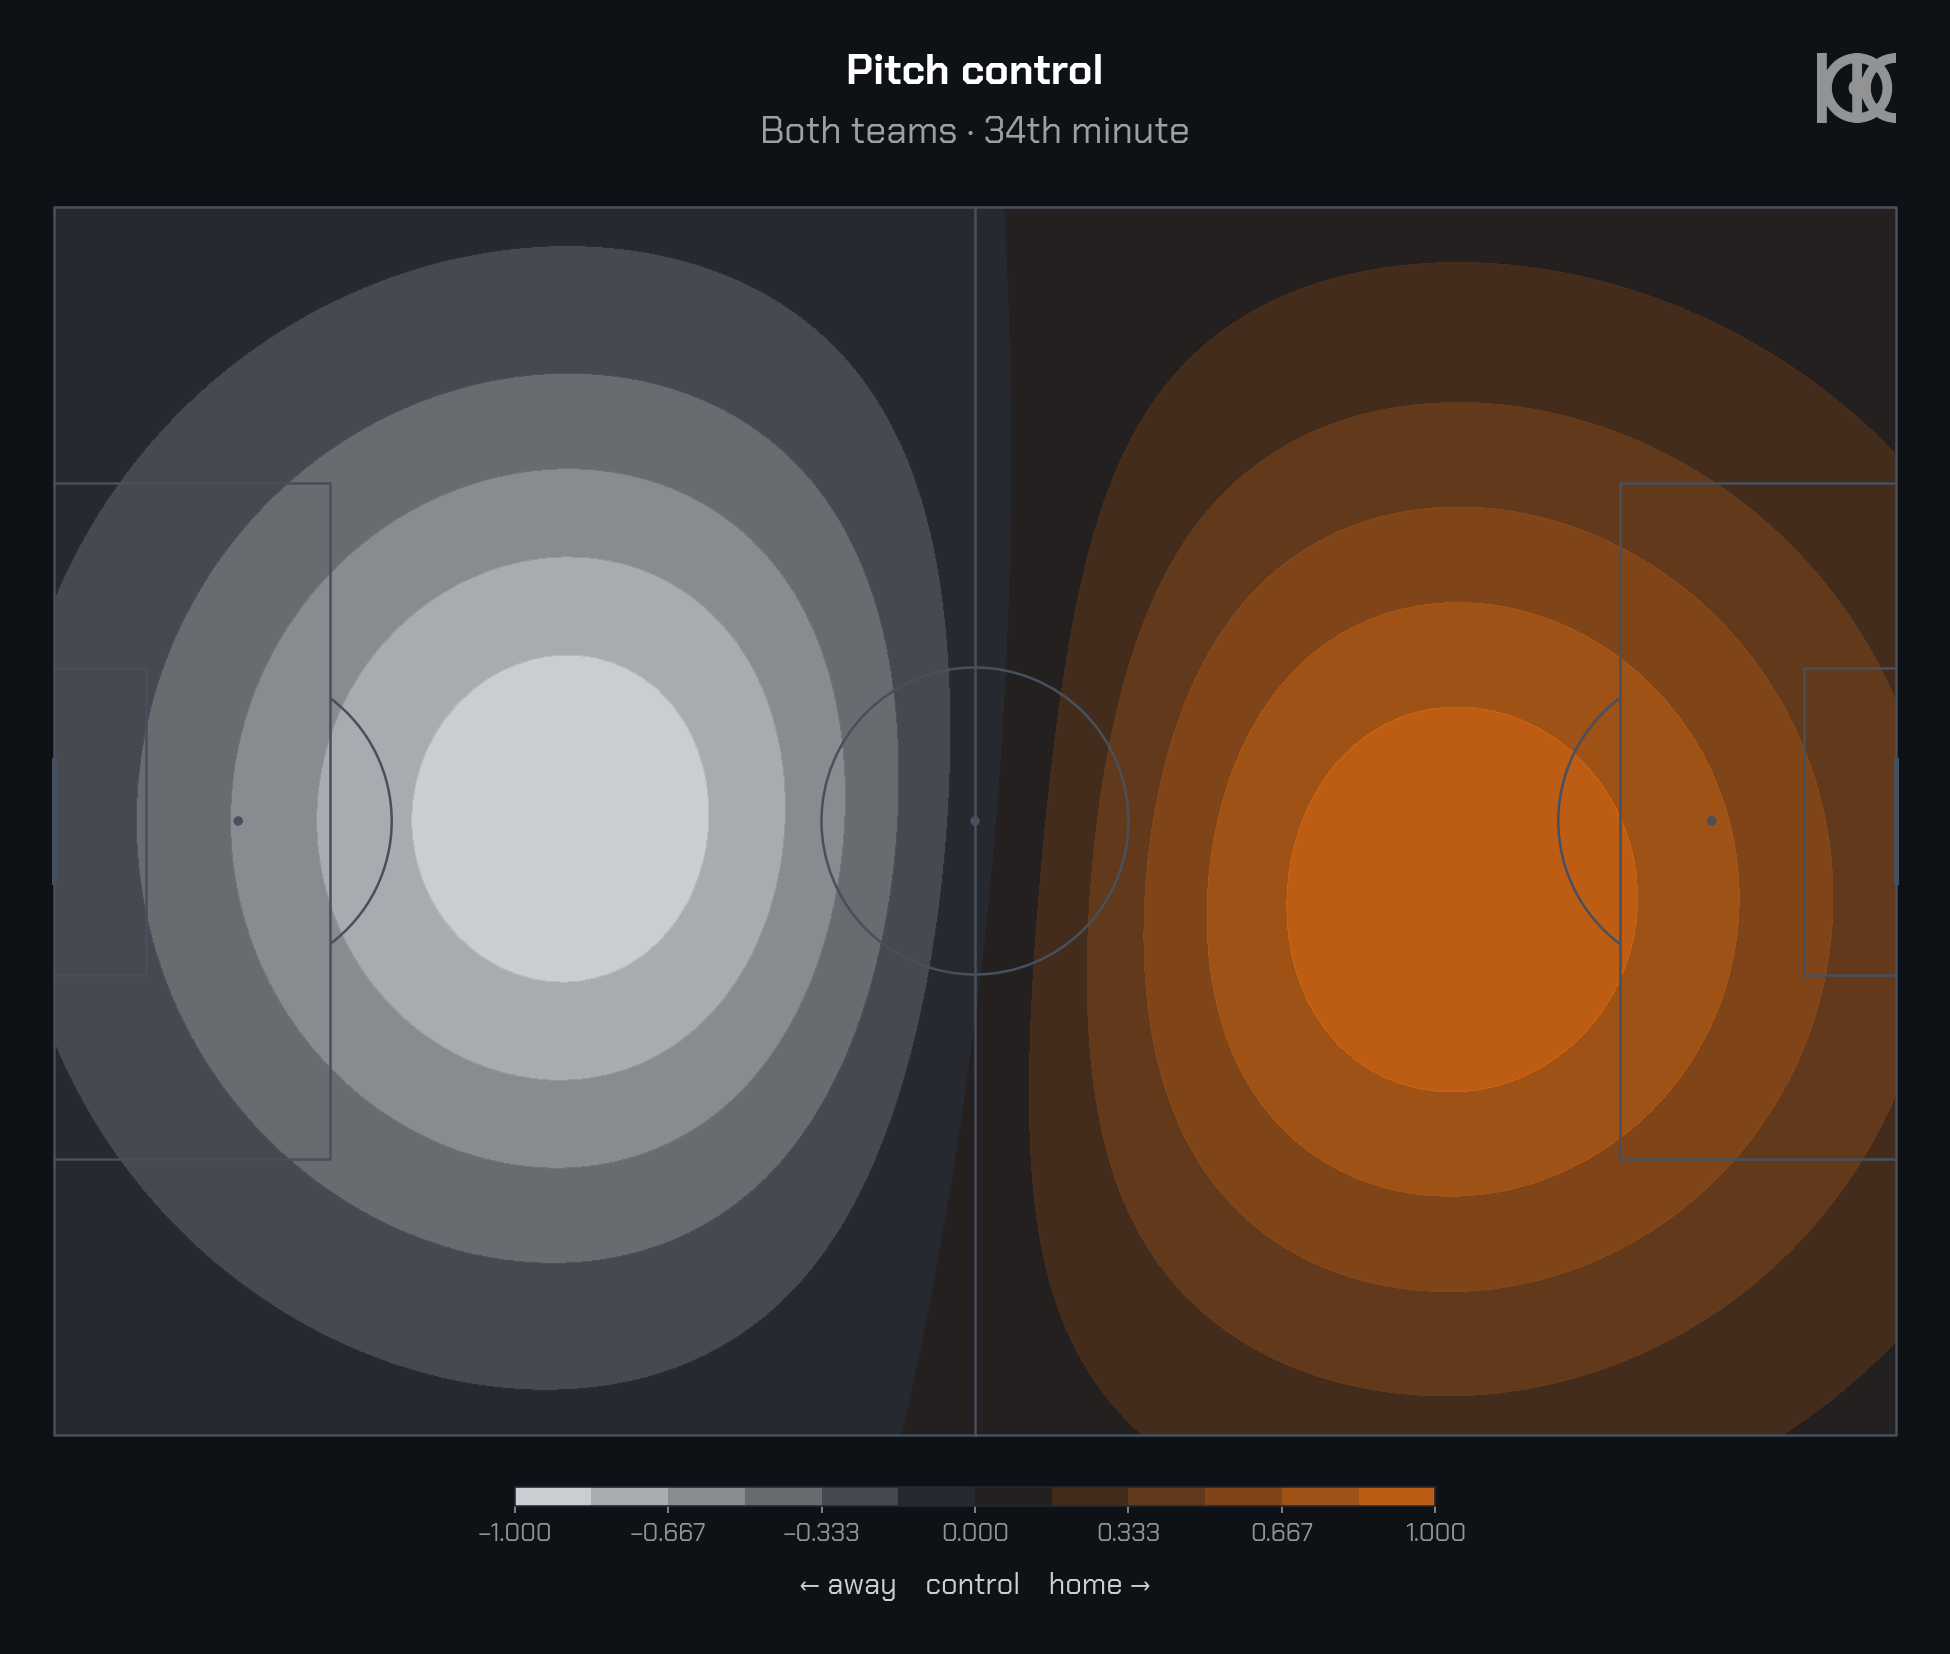

In [10]:
xf = np.linspace(0, 120, 120); yf = np.linspace(0, 80, 80)
gxf, gyf = np.meshgrid(xf, yf)
control = blob(gxf, gyf, [(90, 45, 22, 1.0)]) - blob(gxf, gyf, [(35, 40, 20, 1.0)])

pitch, fig, ax = draw_kick_pitch(line_zorder=3, cbar=True)
m = kick_contour(ax, xf, yf, control, levels=np.linspace(-1, 1, 13), cmap=KICK_DIV, vmin=-1, vmax=1)
kick_cbar(fig, ax, m, "← away    control    home →")
kick_title(fig, ax, "Pitch control", "Both teams · 34th minute")
plt.show()

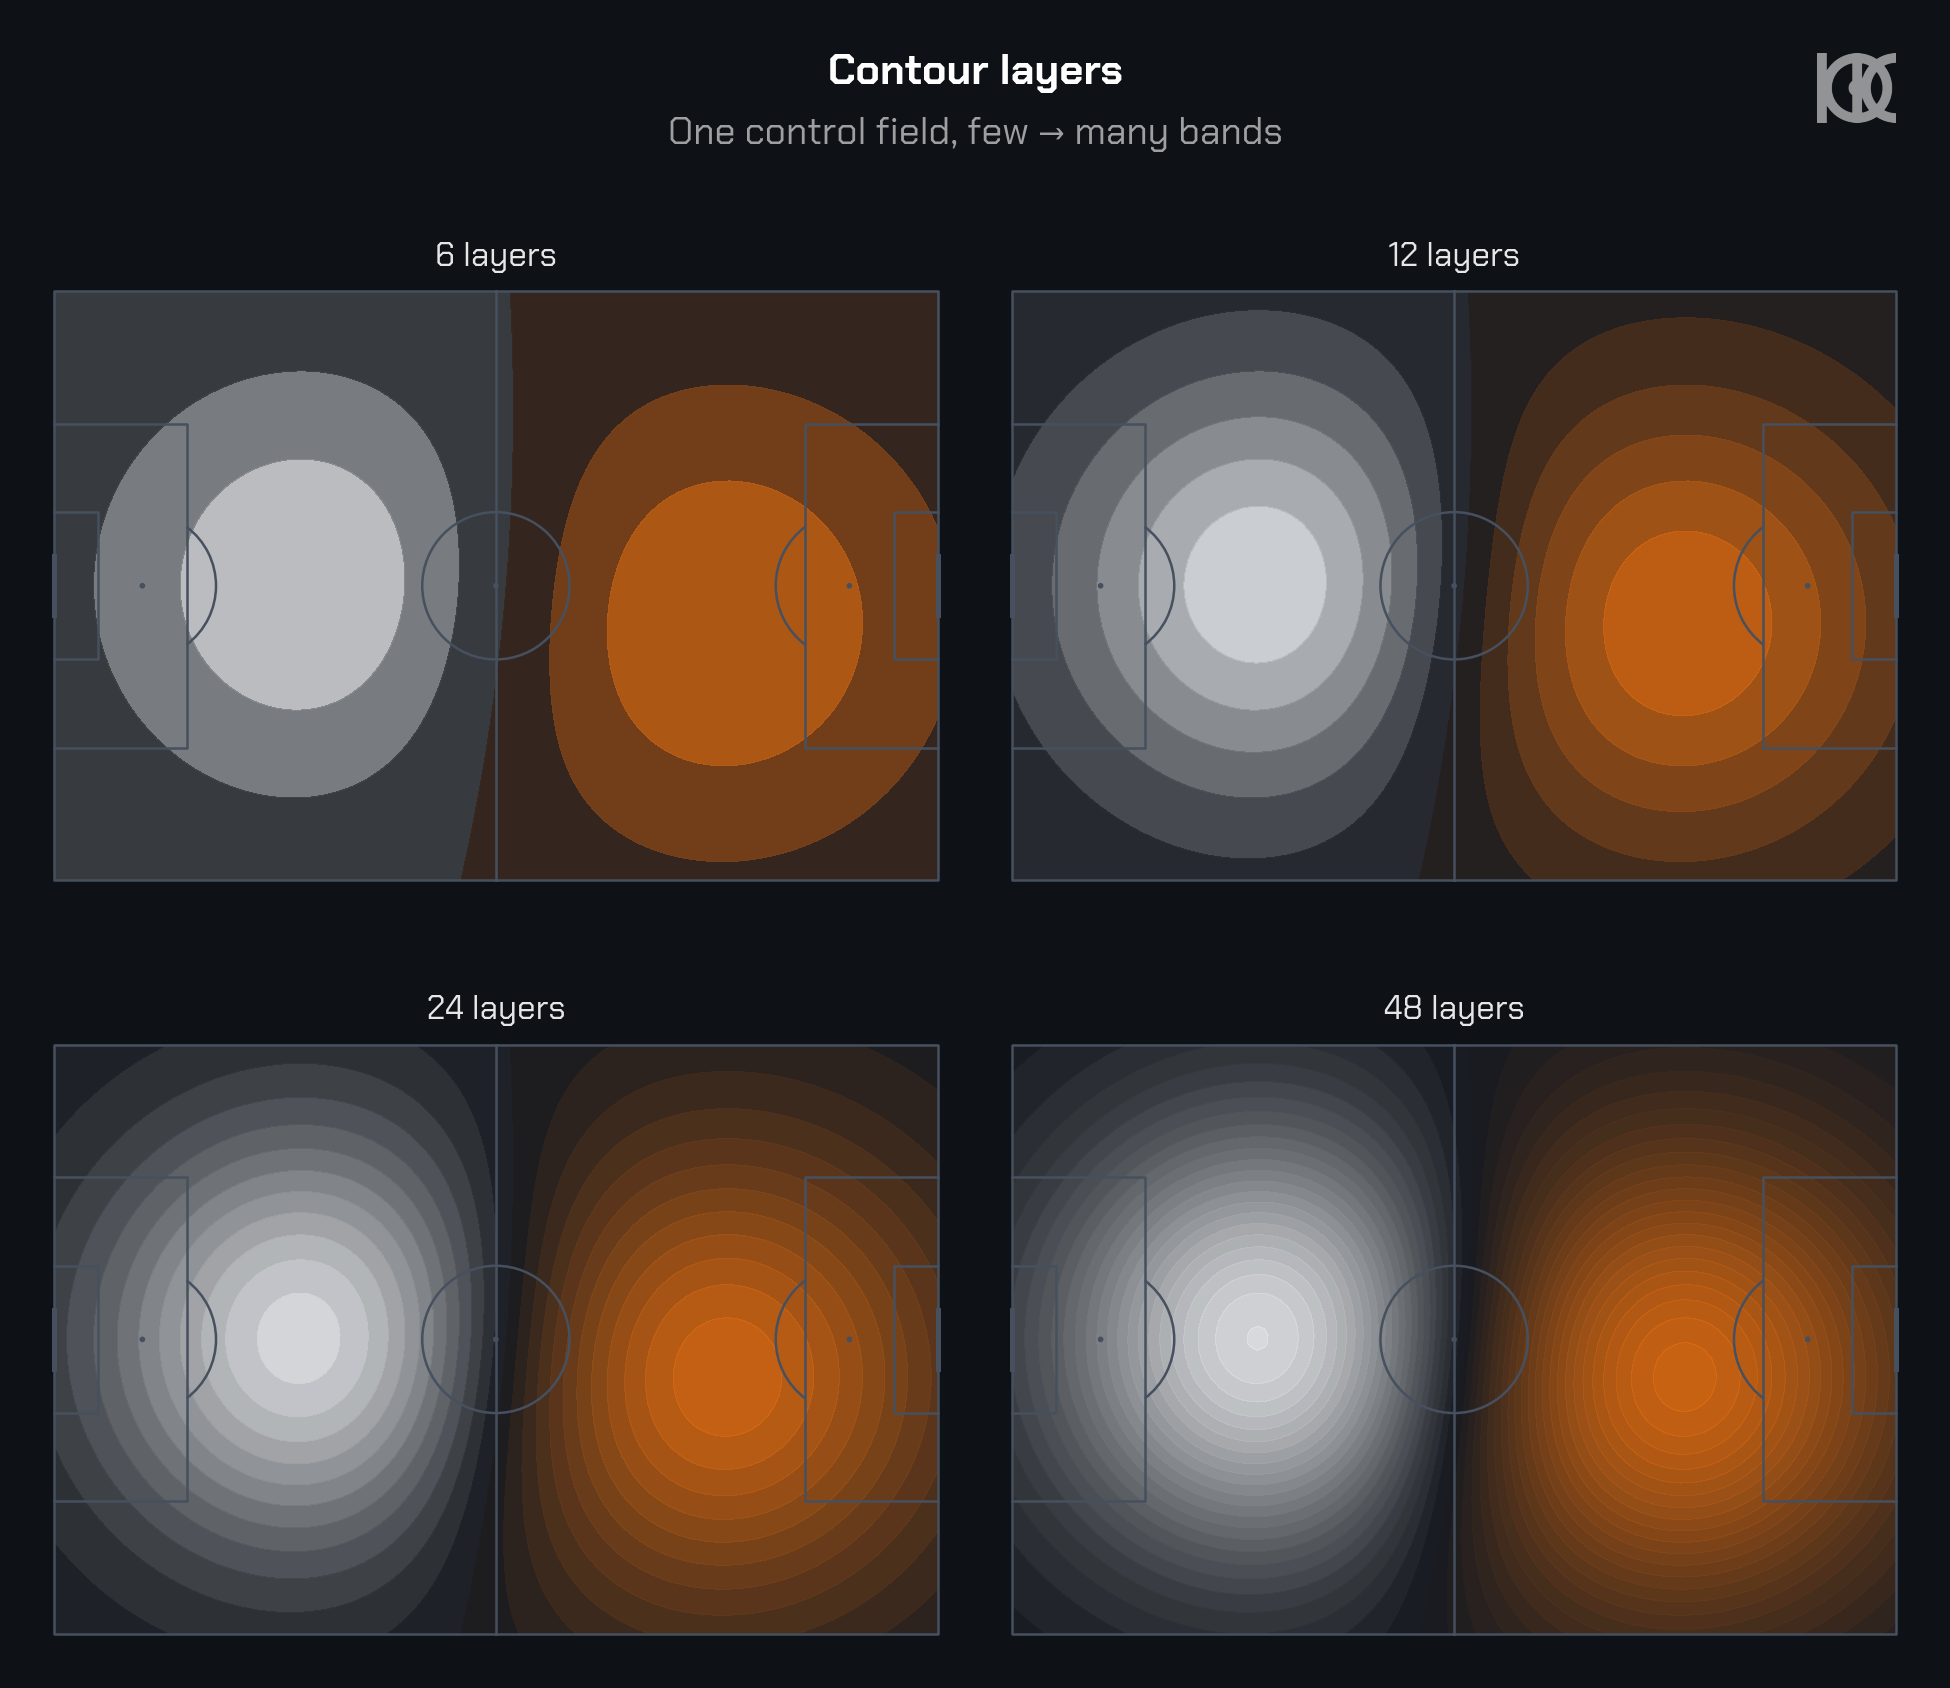

In [11]:
# band count is a knob — the same control field at four layer counts (fewer = blockier bands)
bands = [6, 12, 24, 48]
pitch, fig, axes = kick_grid(2, 2, line_zorder=3)
for ax, n in zip(axes.flat, bands):
    kick_contour(ax, xf, yf, control, levels=np.linspace(-1, 1, n + 1), cmap=KICK_DIV, vmin=-1, vmax=1)
    kick_panel_label(ax, f"{n} layers")
kick_grid_title(fig, axes, "Contour layers", "One control field, few → many bands")
plt.show()

## 6 · Passing network — *categorical 'checker' nodes + weighted edges*

One team's network: a node per player at their mean location, drawn as a beveled **checker** chip via
`kick_checker` (offset shadow → white-rimmed rim → main team colour → highlight cap → jersey number).
Chip size and edge width are set **freely** (continuous — no discrete tiers); the hub is flagged in
accent, edges kept a recessive grey so the chips lead. Pass an optional `name=` to add the player's
name in a rounded black pill above the chip. `kick_checker(ax, x, y, r, color, number=, name=)`.

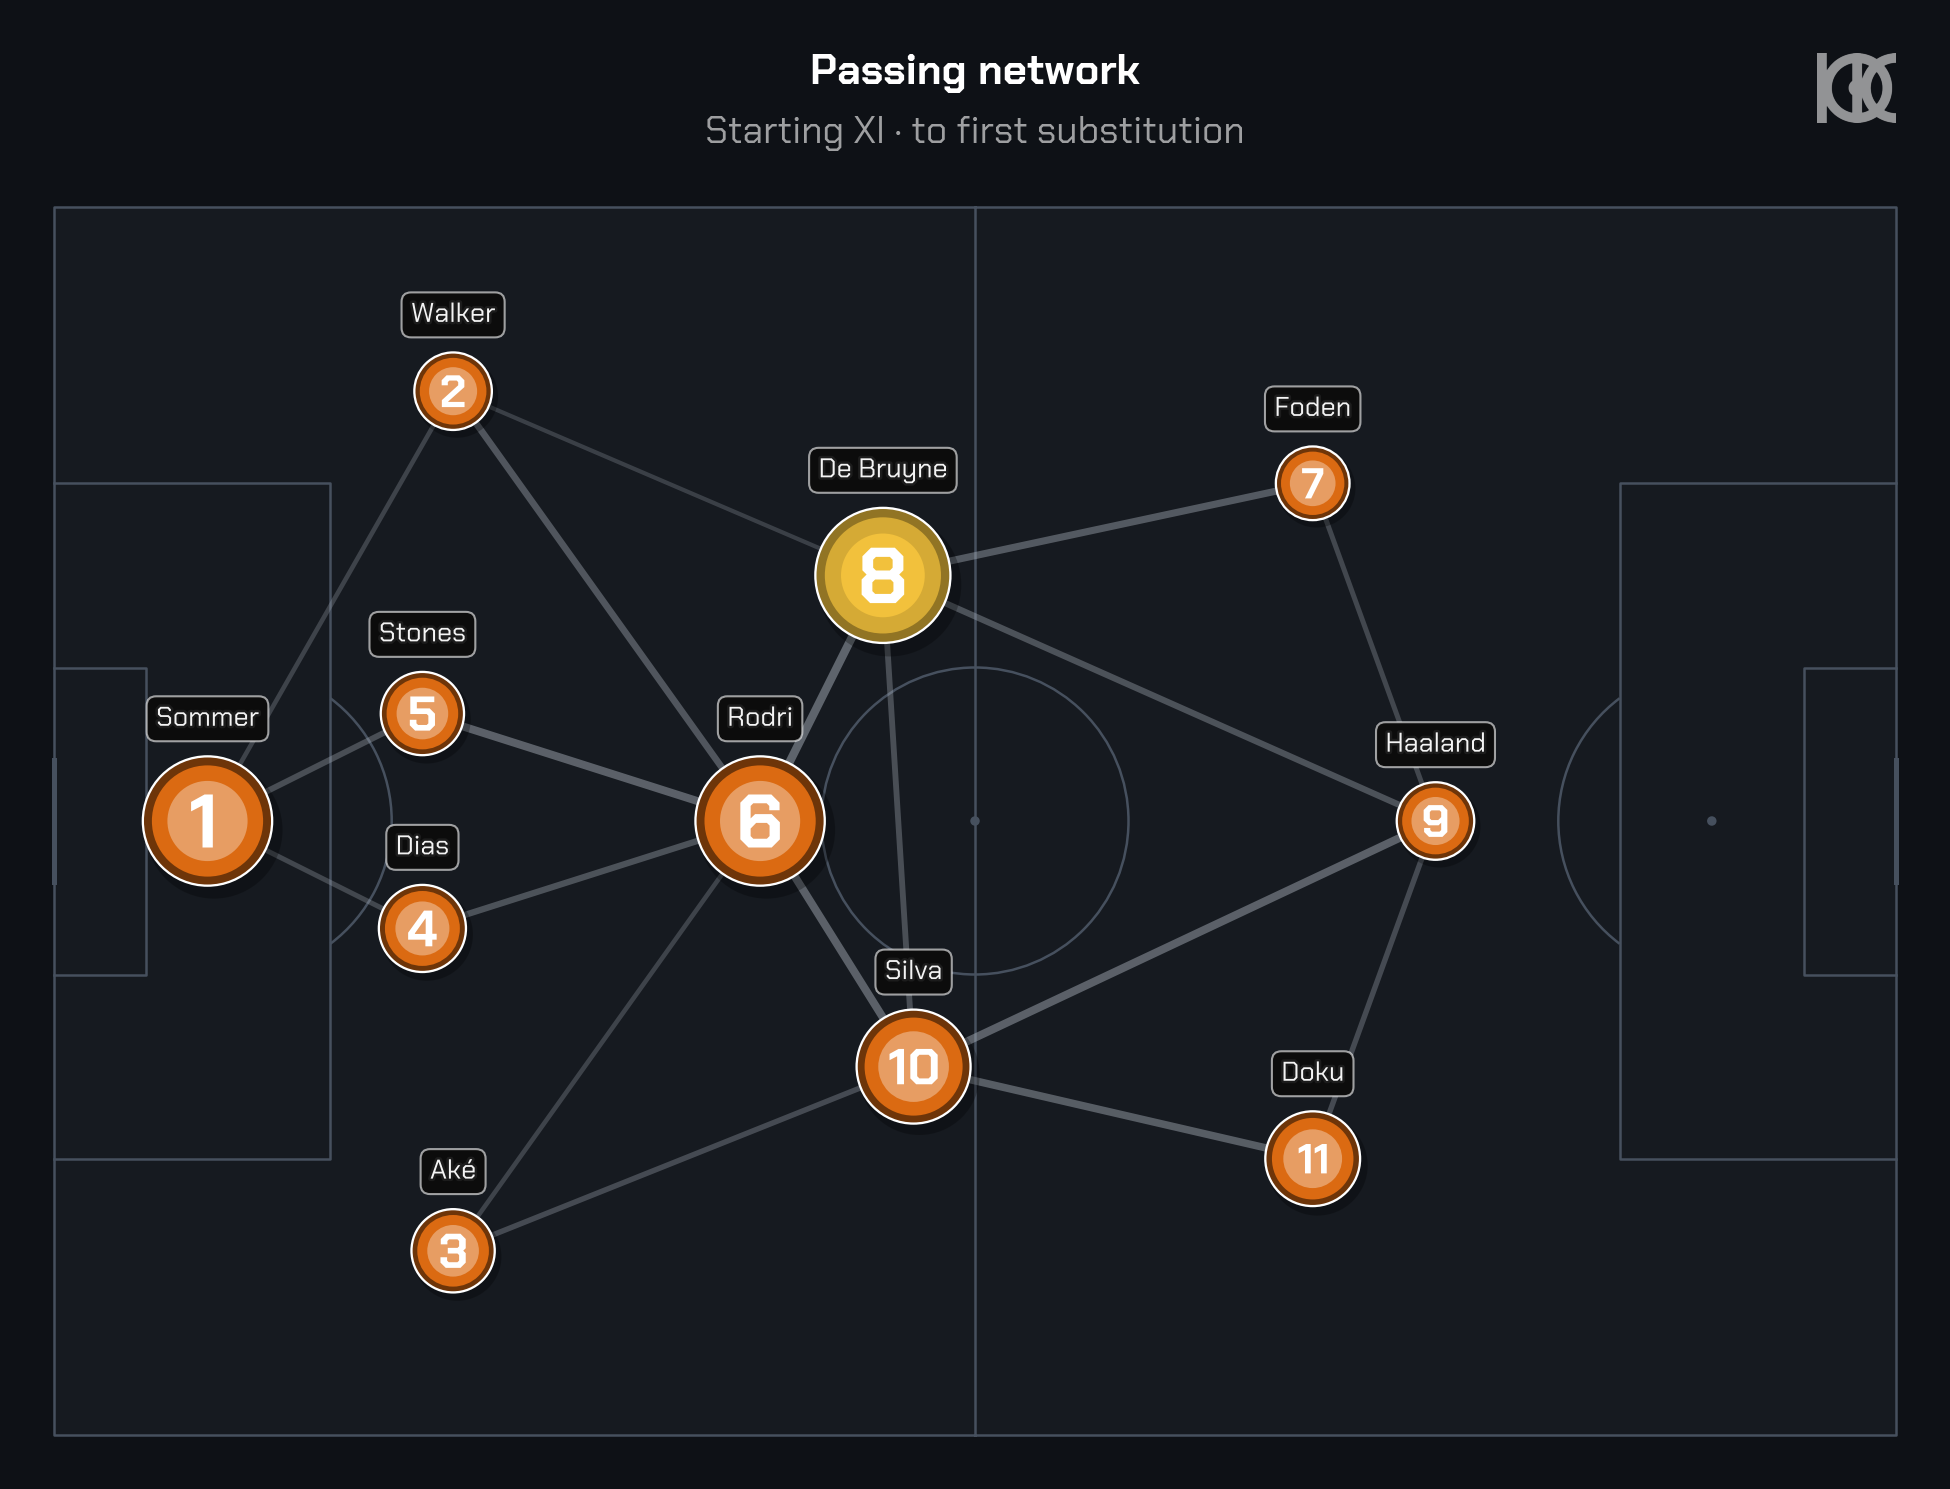

In [12]:
rng = np.random.default_rng(3)
# one team attacking right — 11 players in a rough 4-3-3 (num, x, y)
players = [(1, 10, 40), (2, 26, 12), (5, 24, 33), (4, 24, 47), (3, 26, 68),
           (6, 46, 40), (8, 54, 24), (10, 56, 56),
           (7, 82, 18), (9, 90, 40), (11, 82, 62)]
names = {1: "Sommer", 2: "Walker", 5: "Stones", 4: "Dias", 3: "Aké", 6: "Rodri",
         8: "De Bruyne", 10: "Silva", 7: "Foden", 9: "Haaland", 11: "Doku"}
pos = {n: (x, y) for n, x, y in players}
vol = {n: int(v) for n, v in zip(pos, rng.integers(22, 60, len(players)))}
hub = max(vol, key=vol.get)
edges = [(1, 2, 7), (1, 5, 10), (1, 4, 8), (2, 6, 12), (5, 6, 15), (4, 6, 11), (3, 10, 9),
         (6, 8, 16), (6, 10, 15), (8, 10, 10), (8, 7, 13), (10, 11, 14), (10, 9, 15),
         (8, 9, 11), (7, 9, 8), (11, 9, 9), (6, 3, 7), (2, 8, 6)]
wmax = max(w for *_, w in edges); vmin, vmax = min(vol.values()), max(vol.values())

pitch, fig, ax = draw_kick_pitch()
for a, b, w in edges:
    (x1, y1), (x2, y2) = pos[a], pos[b]
    ax.plot([x1, x2], [y1, y2], color=KICK["ink_soft"], lw=0.8 + 3.2 * w / wmax,
            alpha=0.10 + 0.38 * w / wmax, zorder=2, solid_capstyle="round")
for n, (x, y) in pos.items():
    r = 2.4 + 2.0 * (vol[n] - vmin) / (vmax - vmin)
    kick_checker(ax, x, y, r, KICK["accent"] if n == hub else KICK["home"],
                 number=n, name=names[n])
kick_title(fig, ax, "Passing network", "Starting XI · to first substitution")
plt.show()

**Fail-direction variant** (ported from `passing_network.ipynb`), shown as a **1×2 of vertical pitches
— home (orange) vs away (white)** so both teams' risk profiles sit side by side (the white chips use the
adaptive bevel). Each chip carries a **crack** — a wedge notched into the rim pointing the way that player
loses the ball most (their average failed-pass angle), arc ∝ failure rate; a wide crack toward the
opponent's goal (**upward**) flags risky forward giveaways. `kick_checker(..., fail_angle=deg,
fail_ratio=0..1)` — angles rotated **+90°** for the portrait orientation (forward = up) and horizontal
positions swapped (x↔y) for the vertical pitch.

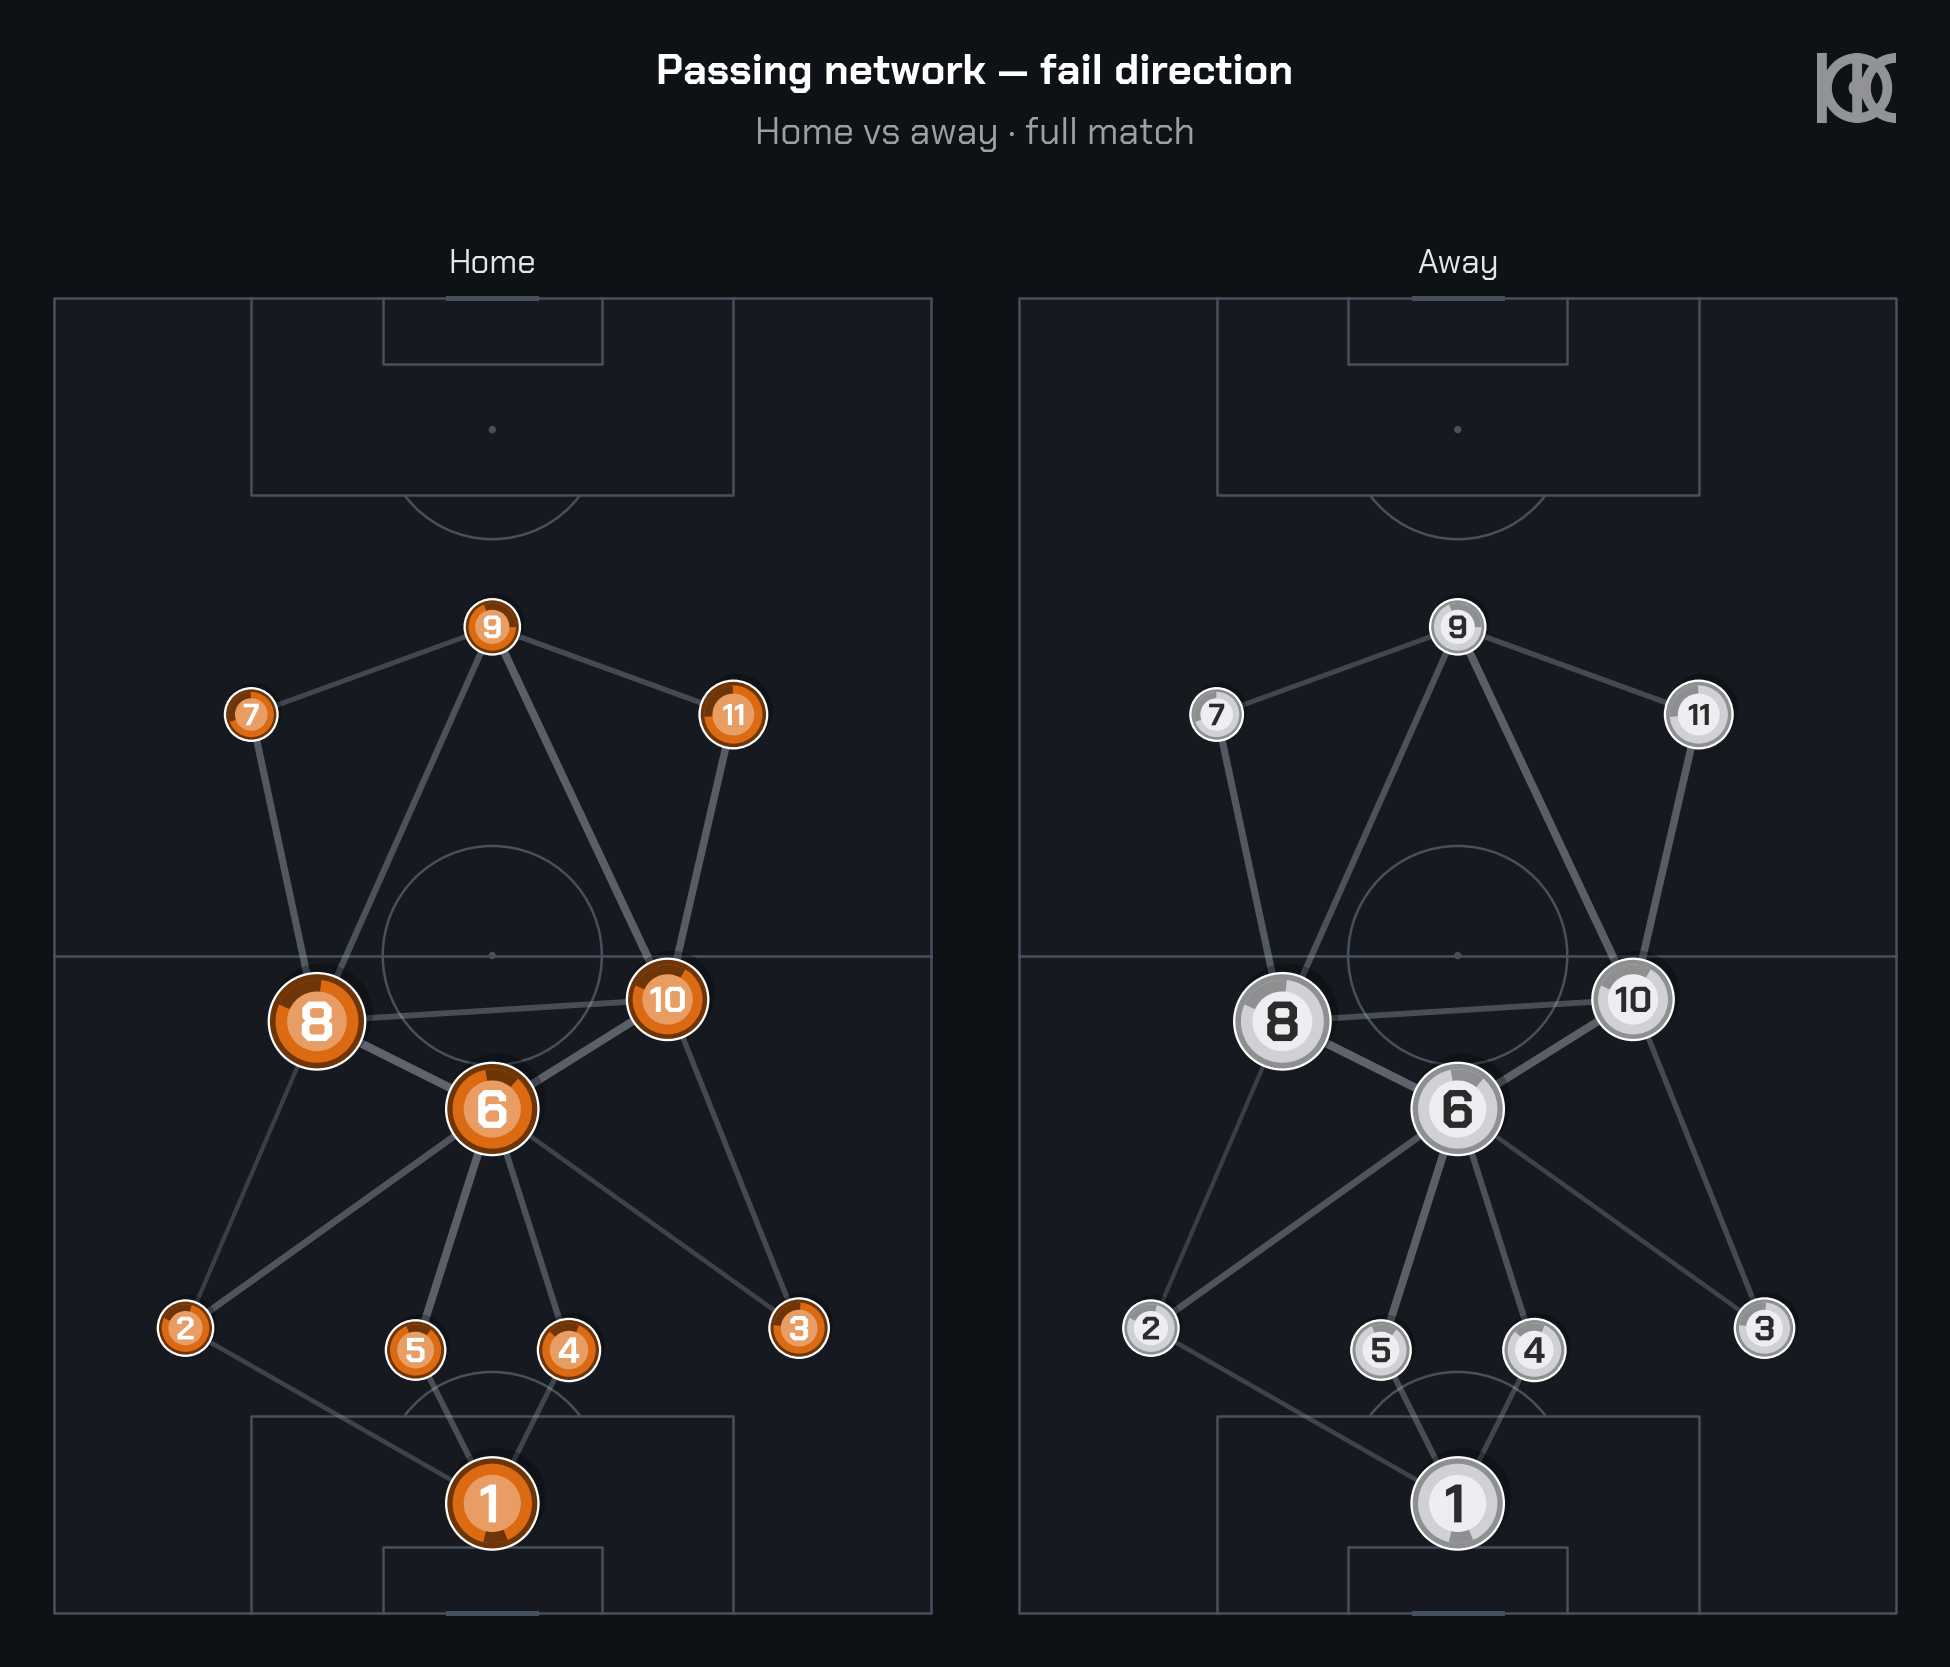

In [13]:
# each player's dominant fail direction (deg, 0 = toward attacking goal) + fail rate
fail = {1: (185, 0.10), 2: (25, 0.22), 5: (-8, 0.16), 4: (12, 0.19), 3: (40, 0.24), 6: (-15, 0.14),
        8: (30, 0.20), 10: (18, 0.27), 7: (55, 0.30), 9: (-35, 0.31), 11: (48, 0.26)}

posv = {n: (y, x) for n, (x, y) in pos.items()}          # swap H coords -> vertical (attacking UP)
pitch, fig, axes = kick_grid(1, 2, vertical=True)         # two vertical pitches: home (orange) · away (white)
for ax, key in zip(axes.flat, ["home", "away"]):
    for a, b, w in edges:
        (x1, y1), (x2, y2) = posv[a], posv[b]
        ax.plot([x1, x2], [y1, y2], color=KICK["ink_soft"], lw=0.8 + 3.2 * w / wmax,
                alpha=0.10 + 0.38 * w / wmax, zorder=2, solid_capstyle="round")
    for n, (x, y) in posv.items():
        r = 2.4 + 2.0 * (vol[n] - vmin) / (vmax - vmin)
        fa, fr = fail[n]
        kick_checker(ax, x, y, r, KICK[key], number=n, fail_angle=fa + 90, fail_ratio=fr)   # +90: forward = up
    kick_panel_label(ax, "Home" if key == "home" else "Away")
kick_grid_title(fig, axes, "Passing network — fail direction", "Home vs away · full match")
plt.show()

## 7 · Curves — *line + soft fill (non-pitch)*

One form, two jobs: the same line-with-low-alpha-fill draws a **distribution** (a density curve) or a
**trend** (a value over time). Coloured by job; the signed/diverging variant is the momentum line in §10.
Non-pitch charts get the house header via `kick_title(..., pitch=False)`.

**Legend by series count** — 1 → **no legend** (the title names it); 2+ → **inside the plot**
(`kick_inside_legend`, emptiest corner on a subtle panel). Legends always sit **inside the graph** now —
the header carries only the centred title/subtitle and a small icon badge top-right, so nothing competes
for the header band. The single chart below uses an inside legend (2 series); the 2×2 after it stress-tests
1 · 2 · 3 · 6 (6 is the cue to switch to direct end-of-line labels).

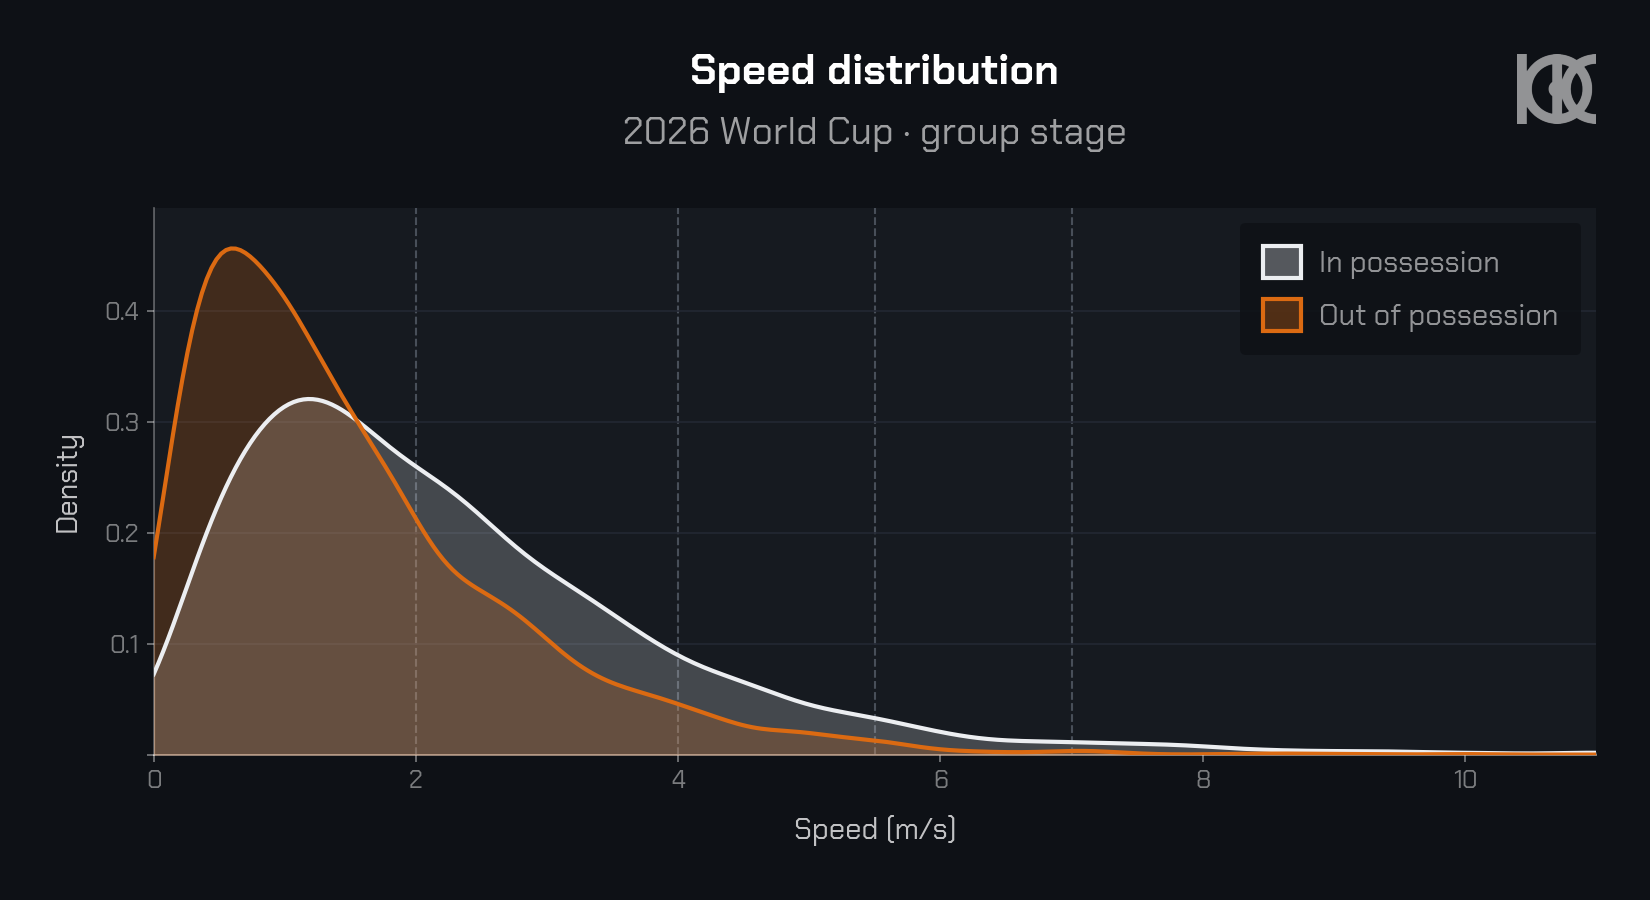

In [14]:
from scipy.stats import gaussian_kde
rng = np.random.default_rng(11)
s_in = np.clip(rng.gamma(2.0, 1.1, 4000), 0, 11); s_out = np.clip(rng.gamma(1.5, 1.0, 4000), 0, 11)
xs = np.linspace(0, 11, 300)

fig, ax = plt.subplots(figsize=(11, 6)); fig.set_facecolor(KICK["figure"])
series = [(s_in, "away", "In possession"), (s_out, "home", "Out of possession")]
dmax = 0.0
for s, key, lab in series:
    d = gaussian_kde(s)(xs); dmax = max(dmax, d.max())
    ax.fill_between(xs, d, color=KICK[key], alpha=0.22, zorder=2)
    ax.plot(xs, d, color=KICK[key], lw=2, zorder=3)
for thr in (2.0, 4.0, 5.5, 7.0):
    ax.axvline(thr, color=KICK["muted"], ls="--", lw=1, alpha=0.6, zorder=1)
ax.set_xlim(0, 11); ax.set_ylim(0, dmax * 1.08)   # pin y=0 to the x-axis so the fill meets the baseline
ax.set_xlabel("Speed (m/s)"); ax.set_ylabel("Density")
ax.grid(axis="y")
kick_hide_origin_zero(ax)   # one 0 at the origin (drop y's 0.0; the x-axis "0" serves both)
kick_title(fig, ax, "Speed distribution", "2026 World Cup · group stage", pitch=False)
# legend INSIDE the plot (house rule): the curves peak left, so the emptiest corner is top-right
kick_inside_legend(ax, handles=[kick_swatch(KICK[key], lab) for _, key, lab in series], loc="upper right")
plt.show()

**Showcase — legend by series count (1 · 2 · 3 · 6).** 1 needs none; 2/3 sit cleanly inside; by 6
an inside legend is busy — switch to direct end-of-line labels. (In a single full chart, 2 would use the
header legend instead of inside.)

[margins  OK ] §7 curves 2×2        L=0.360 R=0.360 T=0.360 B=0.360


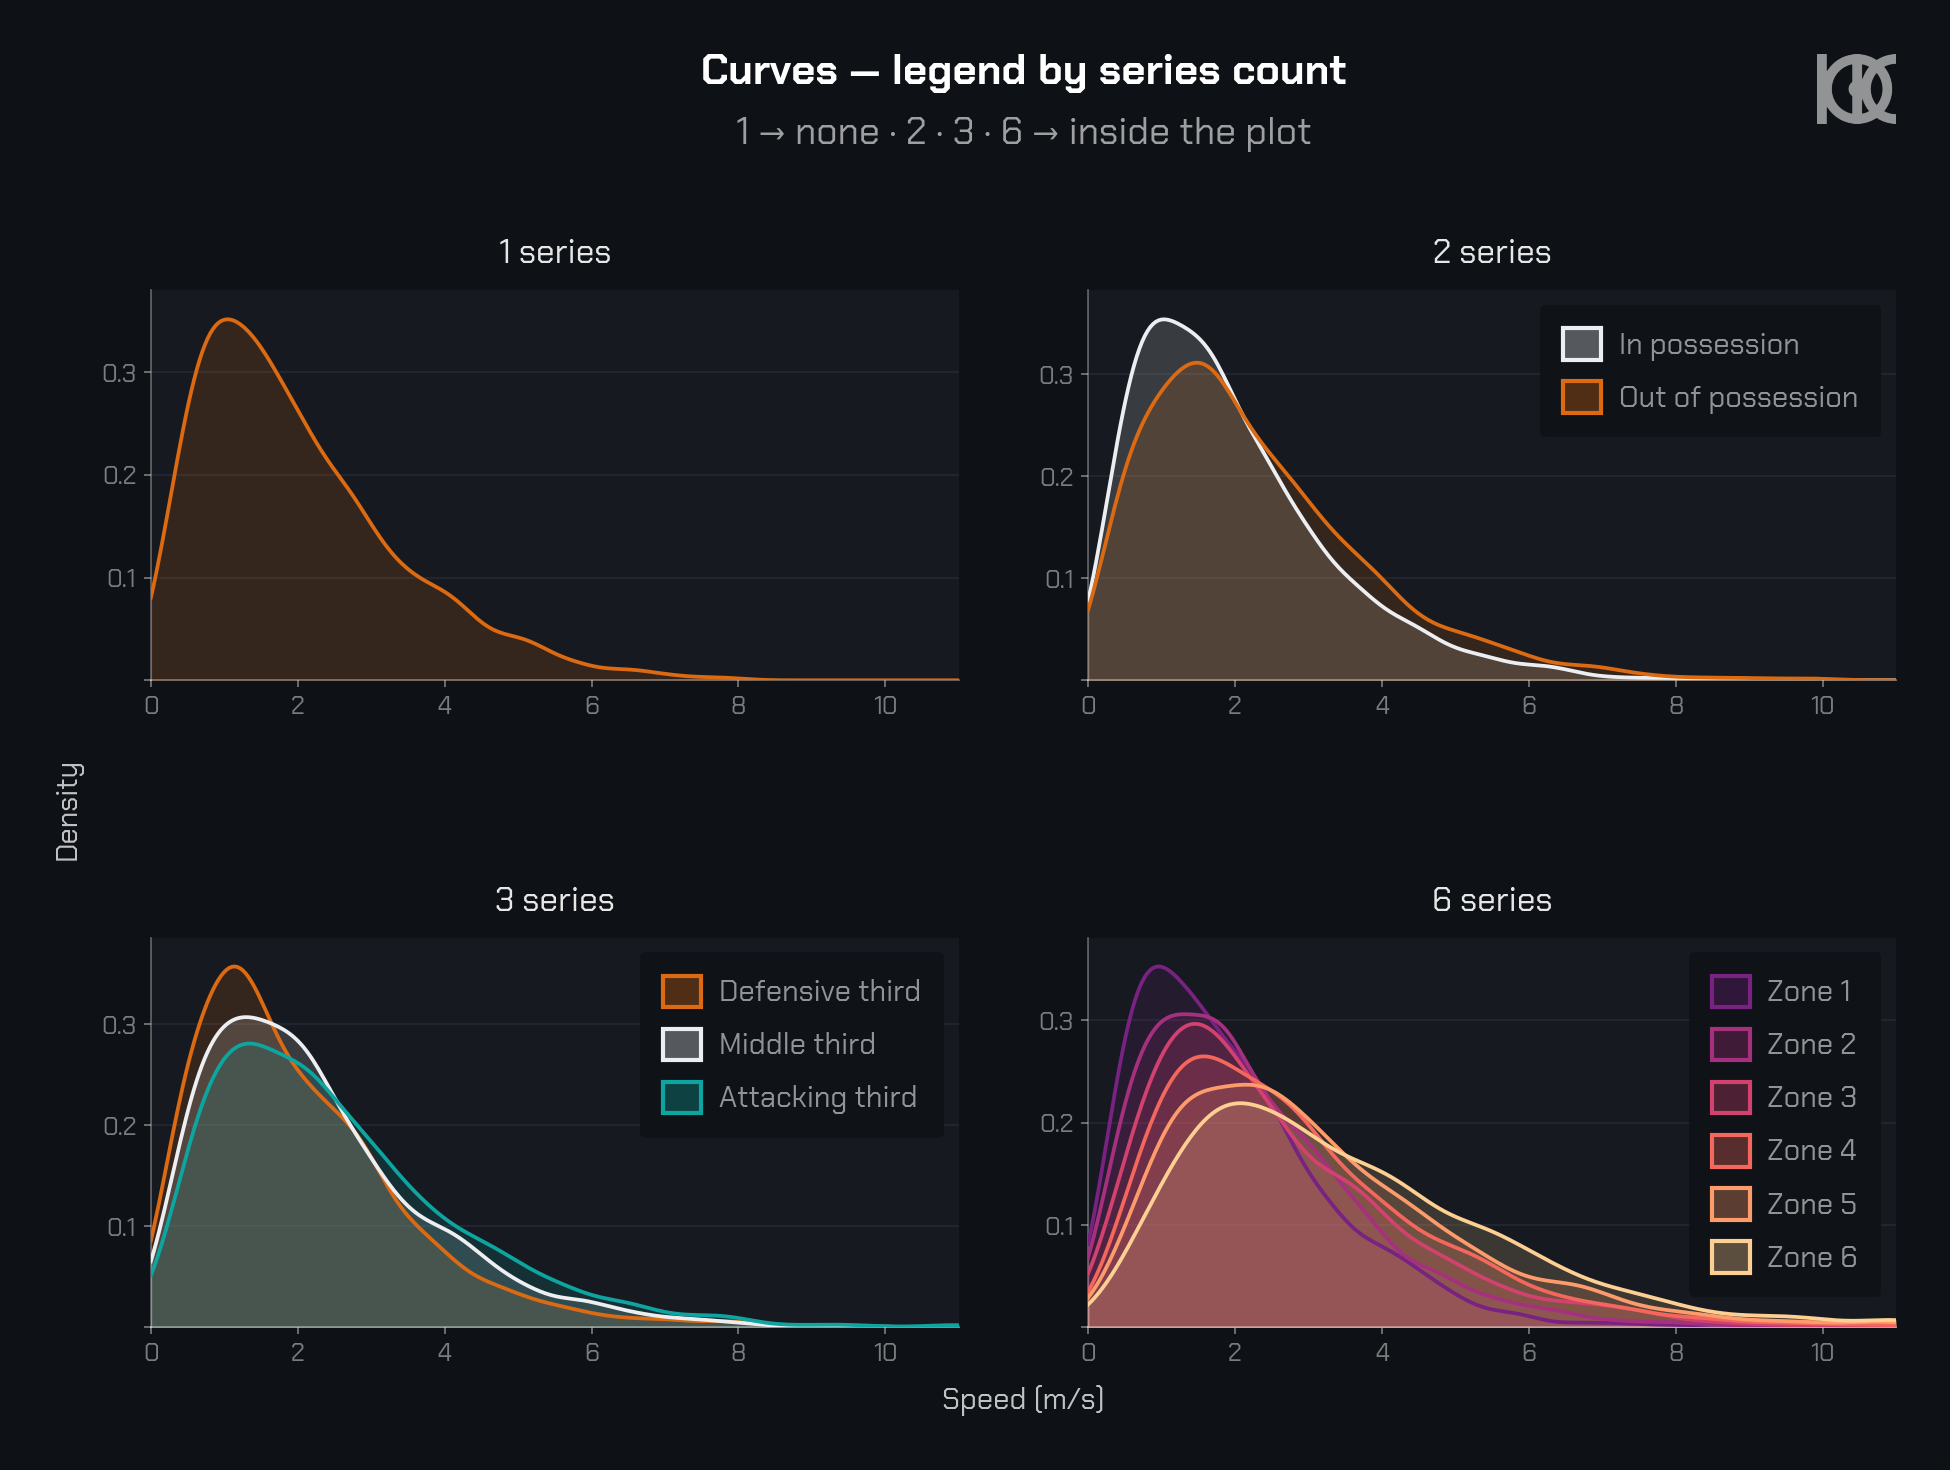

In [15]:
rng2 = np.random.default_rng(4)
mag6 = plt.cm.magma(np.linspace(0.35, 0.9, 6))
scenarios = {
    1: [(KICK["home"], "Full match")],
    2: [(KICK["away"], "In possession"), (KICK["home"], "Out of possession")],
    3: [(KICK["home"], "Defensive third"), (KICK["away"], "Middle third"), (KICK["teal"], "Attacking third")],
    6: [(mag6[i], f"Zone {i + 1}") for i in range(6)]}

fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.8)); fig.set_facecolor(KICK["figure"])   # taller: room for tall legends
legs = {}
for ax, n in zip(axes.flat, [1, 2, 3, 6]):
    ax.set_facecolor(KICK["panel"]); dmax = 0.0; handles = []
    for i, (col, lab) in enumerate(scenarios[n]):
        d = gaussian_kde(np.clip(rng2.gamma(2.0 + 0.13 * i, 1.0 + 0.06 * i, 2400), 0, 11))(xs)
        dmax = max(dmax, d.max())
        ax.fill_between(xs, d, color=col, alpha=0.16, zorder=2)
        ax.plot(xs, d, color=col, lw=1.8, zorder=3)
        handles.append(kick_swatch(col, lab))
    ax.set_xlim(0, 11); ax.set_ylim(0, dmax * 1.08); ax.grid(axis="y")
    ax.set_title(f"{n} series", color=W(0.90), fontsize=16, loc="center", pad=13)
    kick_hide_origin_zero(ax)                             # one 0 at the origin
    if n > 1:                                             # legend upper-right; reserved below AFTER layout
        legs[ax] = (kick_inside_legend(ax, handles=handles, loc="upper right"), dmax)
# ONE golden-rule call: solves the margins to 0.36" on all sides, draws the centred header + icon,
# and ONE shared axis label per axis (all panels share Density vs Speed) — no hand-tuned subplots_adjust.
kick_grid_header(fig, axes, "Curves — legend by series count",
                 "1 → none · 2 · 3 · 6 → inside the plot", xlabel="Speed (m/s)", ylabel="Density")
for ax, (leg, dmax) in legs.items():                     # AFTER the layout is final, push the curves down so
    kick_reserve_legend(ax, leg, dmax=dmax)              # local: keeps each panel's data as tall as its legend allows     # the legend clears every curve — even the 6-series box
kick_verify_margins(fig, label="§7 curves 2×2")
plt.show()

## 8 · Bars — *ordinal magnitude & grouped comparison (non-pitch)*

A single series → **one hue stepped light→dark** (a magma sample; the order lives in the colour), values
direct-labelled. For **grouped** bars (groups compared across metrics) colour is **categorical**, by group,
in fixed order — **home · away · teal · purple** (`KICK_CAT`; 2 teams → home/away; 3 → +teal; 4 → +purple). If the
groups are themselves **ordinal** (defensive → middle → attacking thirds) use a one-hue **ramp** instead —
it encodes the order. Grouped bars keep top **headroom** so an inside legend (`kick_inside_legend`) clears them.

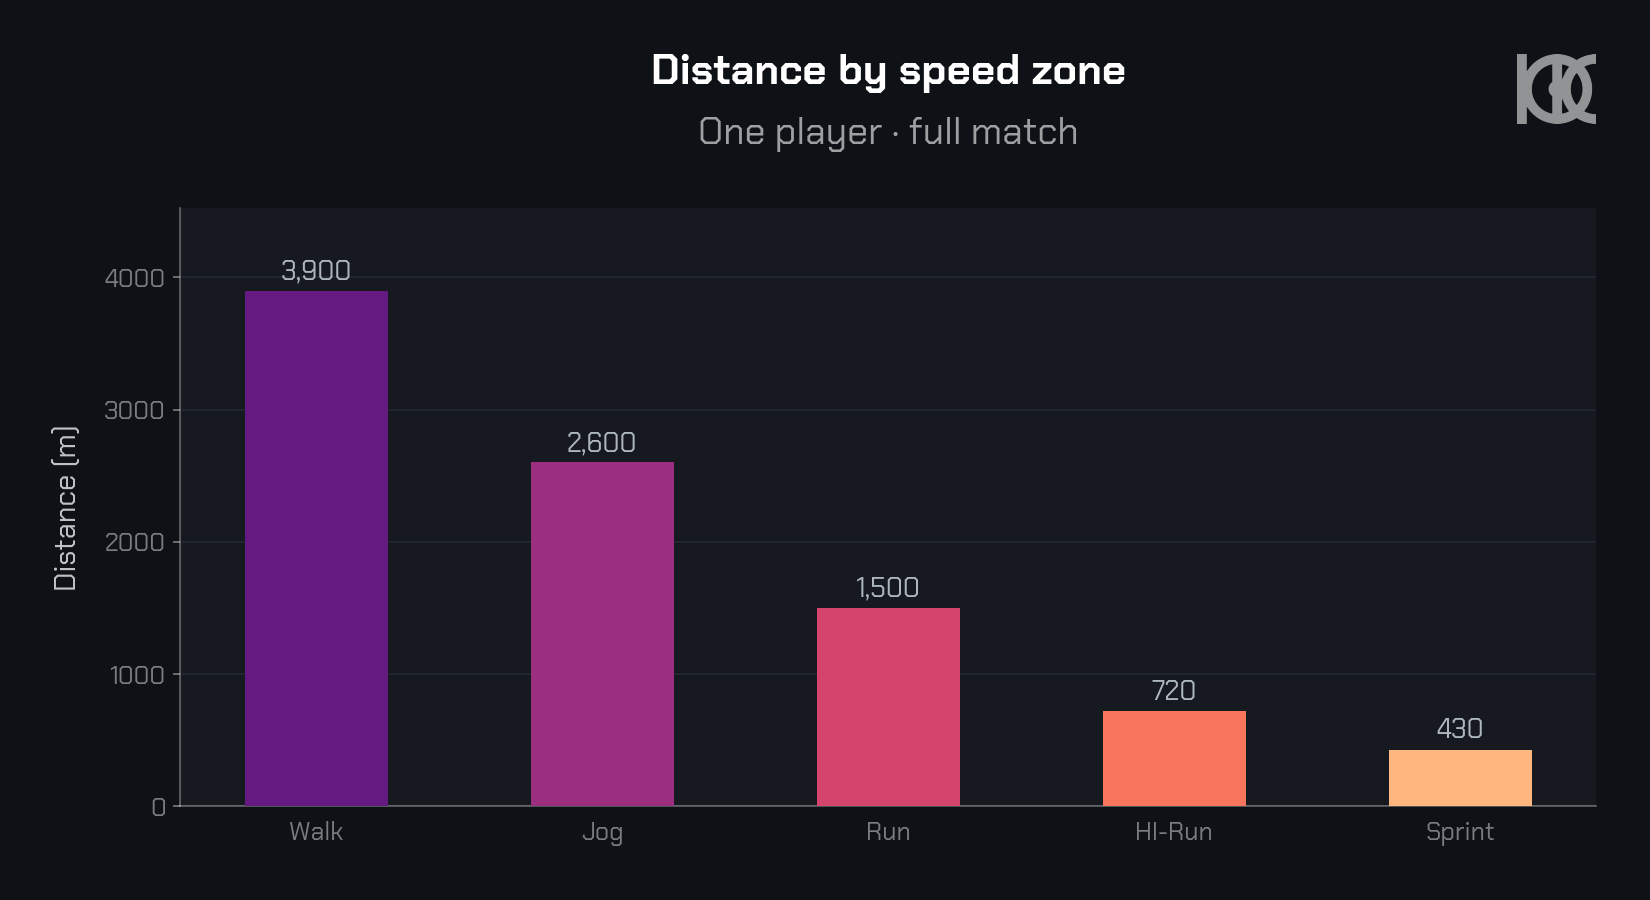

In [16]:
zones = ["Walk", "Jog", "Run", "HI-Run", "Sprint"]; dist = [3900, 2600, 1500, 720, 430]
ramp = plt.cm.magma(np.linspace(0.30, 0.85, len(zones)))
fig, ax = plt.subplots(figsize=(11, 6)); fig.set_facecolor(KICK["figure"])
bars = ax.bar(zones, dist, color=ramp, width=0.5, zorder=3)
for b, v in zip(bars, dist):
    ax.text(b.get_x() + b.get_width() / 2, v + 40, f"{v:,}", ha="center", va="bottom",
            color=KICK["ink_soft"], fontsize=13)
ax.set_ylabel("Distance (m)"); ax.set_ylim(0, max(dist) * 1.16); ax.grid(axis="y"); ax.tick_params(bottom=False)
kick_title(fig, ax, "Distance by speed zone", "One player · full match", pitch=False)
plt.show()

**Showcase — single & grouped (colour by job).** Ordinal single → magma ramp · 2/3 groups →
categorical (home·away·teal) · ordinal groups (thirds) → magma ramp. Grouped panels use a **fixed top
headroom** (×1.72) so the inside legend clears the bars **and the grid stays on one comparable scale** (bars
are tall in every category, so a per-panel reserve would give each a different y-axis); the y-ticks now span
that whole headroom (0,10,…,60) instead of stopping at the data. The whole 2×2 carries **one shared y-axis
label** (not a per-panel label) since every panel is measured in the same metric.

[margins  OK ] §8 bars 2×2          L=0.360 R=0.360 T=0.360 B=0.360


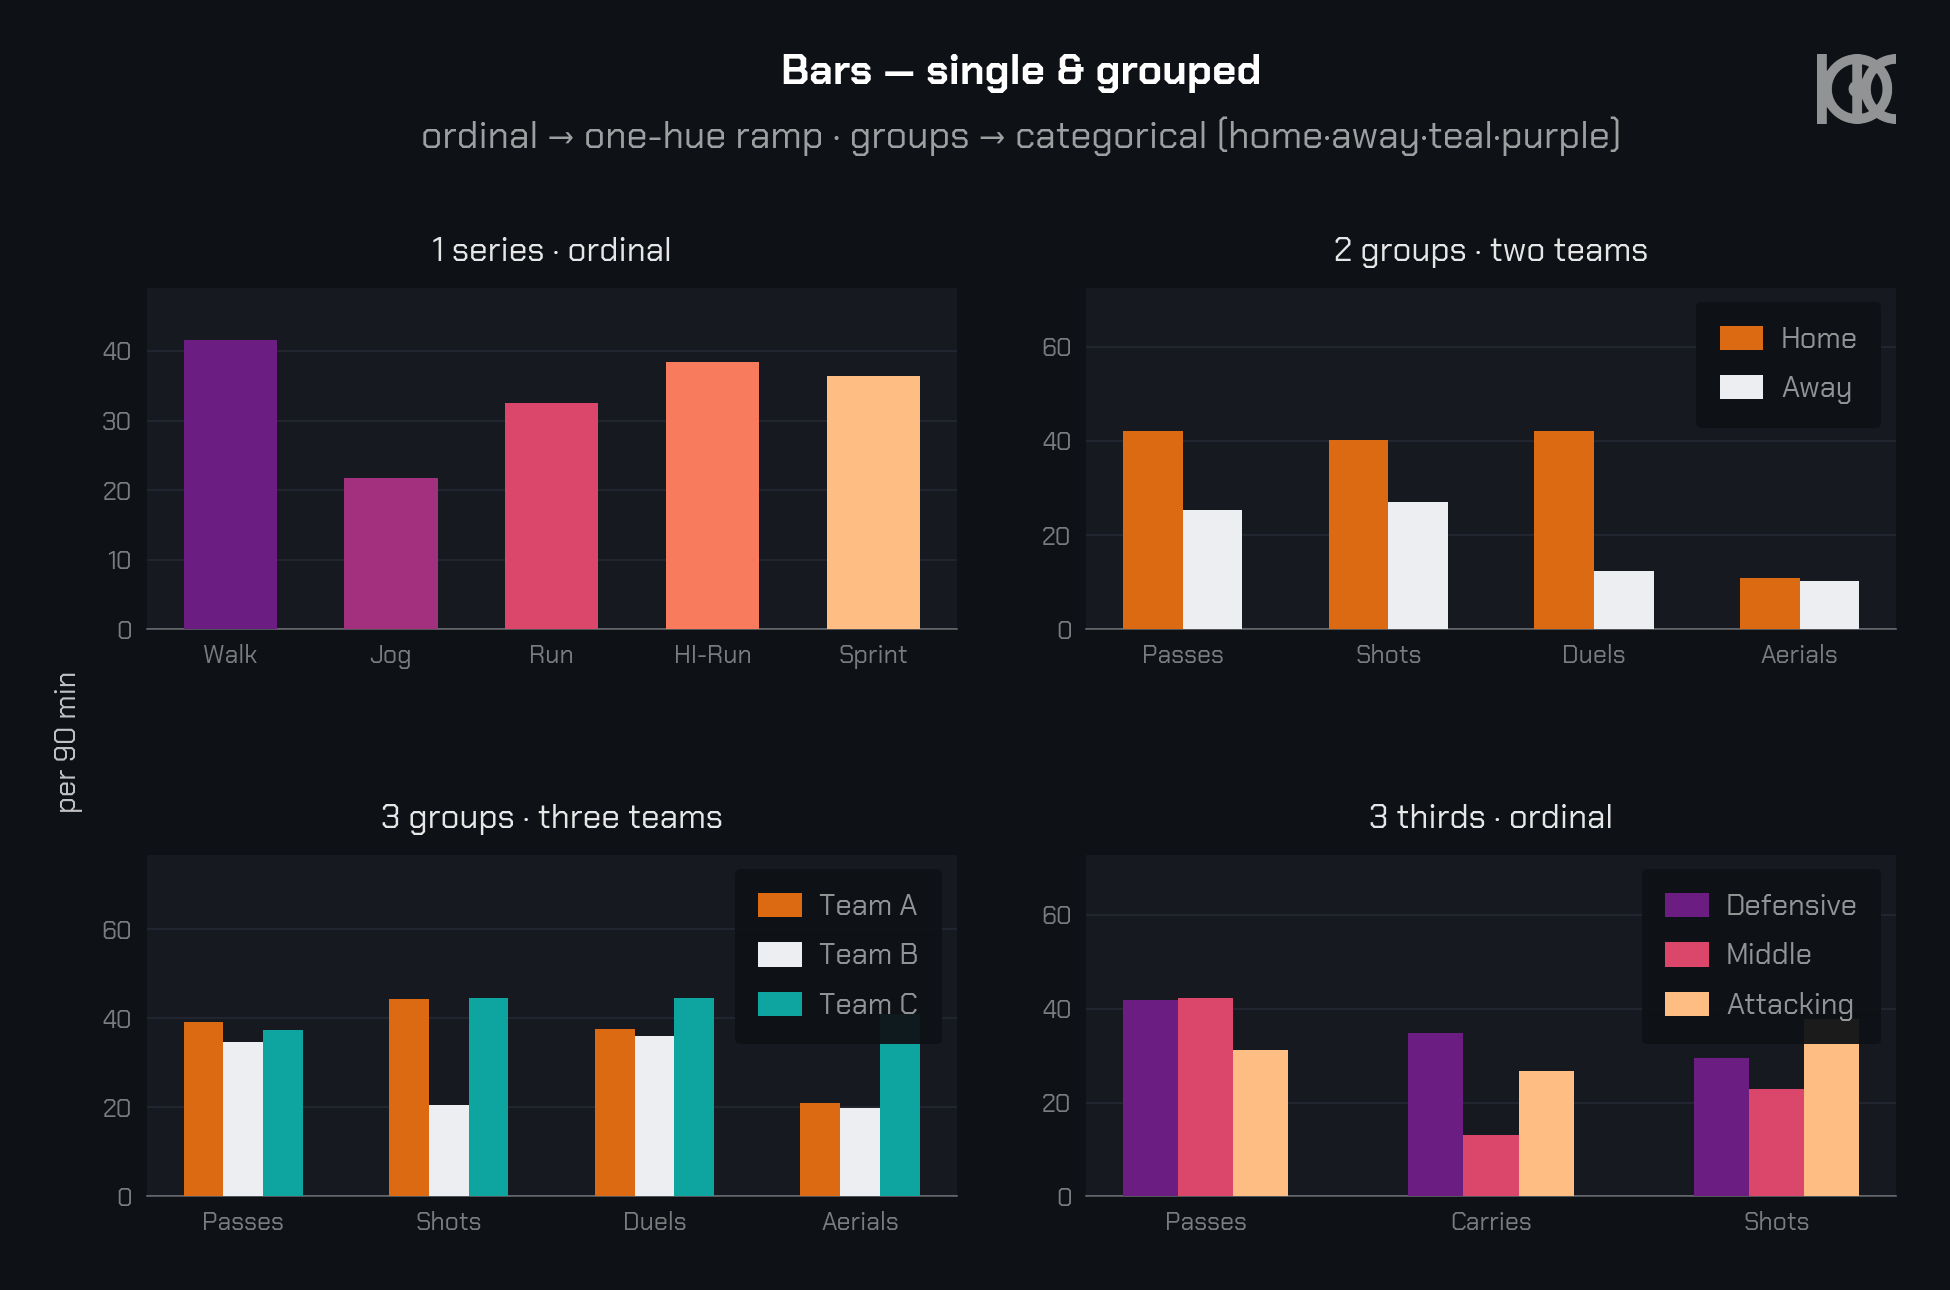

In [17]:
rngb = np.random.default_rng(9)
CAT = ["Passes", "Shots", "Duels", "Aerials"]
mag = lambda k: plt.cm.magma(np.linspace(0.32, 0.86, k))
panels = [("1 series · ordinal", ["Walk", "Jog", "Run", "HI-Run", "Sprint"], rngb.uniform(12, 46, (1, 5)), mag(5), None),
          ("2 groups · two teams", CAT, rngb.uniform(10, 45, (2, 4)), KICK_CAT[:2], ["Home", "Away"]),
          ("3 groups · three teams", CAT, rngb.uniform(10, 45, (3, 4)), KICK_CAT[:3], ["Team A", "Team B", "Team C"]),
          ("3 thirds · ordinal", ["Passes", "Carries", "Shots"], rngb.uniform(10, 45, (3, 3)), mag(3),
           ["Defensive", "Middle", "Attacking"])]

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.6)); fig.set_facecolor(KICK["figure"])
for ax, (title, cats, vals, cols, glab) in zip(axes.flat, panels):
    ax.set_facecolor(KICK["panel"]); ax.set_axisbelow(True)
    x = np.arange(len(cats)); ng = len(vals); w = 0.58 / ng          # thinner bars
    for g in range(ng):
        ax.bar(x + (g - (ng - 1) / 2) * w, vals[g], w, color=(cols[g] if glab else cols),
               label=(glab[g] if glab else None), zorder=3, edgecolor="none")
    dmax = vals.max()
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_ylim(0, dmax * (1.72 if glab else 1.18))                                   # fixed headroom so the legend fits,
    ax.grid(axis="y"); ax.tick_params(left=False, bottom=False)                       #   CONSISTENT across the grid; ticks
    #   now span the whole axis (0,10,…,60) — no trimming to the data range. Bars are tall everywhere, so a local reserve
    #   (used for the curves) would give each panel a different scale; a fixed headroom keeps the grid comparable.
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.set_title(title, color=W(0.90), fontsize=16, loc="center", pad=13)
    if glab:
        kick_inside_legend(ax, loc="upper right", handlelength=1.5, handleheight=0.9, framealpha=0.94)
# golden-rule call: solves the margins + centred header + icon; ONE shared y-label (every panel is per-90),
# and NO shared x-label since each panel compares different categories.
kick_grid_header(fig, axes, "Bars — single & grouped",
                 "ordinal → one-hue ramp · groups → categorical (home·away·teal·purple)", ylabel="per 90 min")
kick_verify_margins(fig, label="§8 bars 2×2")
plt.show()

## 9 · Scatter — *two metrics · quadrants (non-pitch)*

The analytics workhorse: each point is a team (or player) placed by **two metrics**, with median crosshairs
splitting the field into four quadrants (distinct from the on-pitch position scatter in §3 — here the axes
*are* the data). When points **cluster**, on-top names collide, so **`kick_smart_labels`** de-collides them
automatically (a hybrid): **tight clusters** (≥ 4) become **numbered gold badges** mapped in a corner key;
**small groups** (2–3) get **displaced labels + connectors**; **isolated** points keep a plain label. It
proximity-groups by `eps` and picks the method by group size (`tight`, default 4).

[margins  OK ] §9 scatter           L=0.360 R=0.360 T=0.360 B=0.360


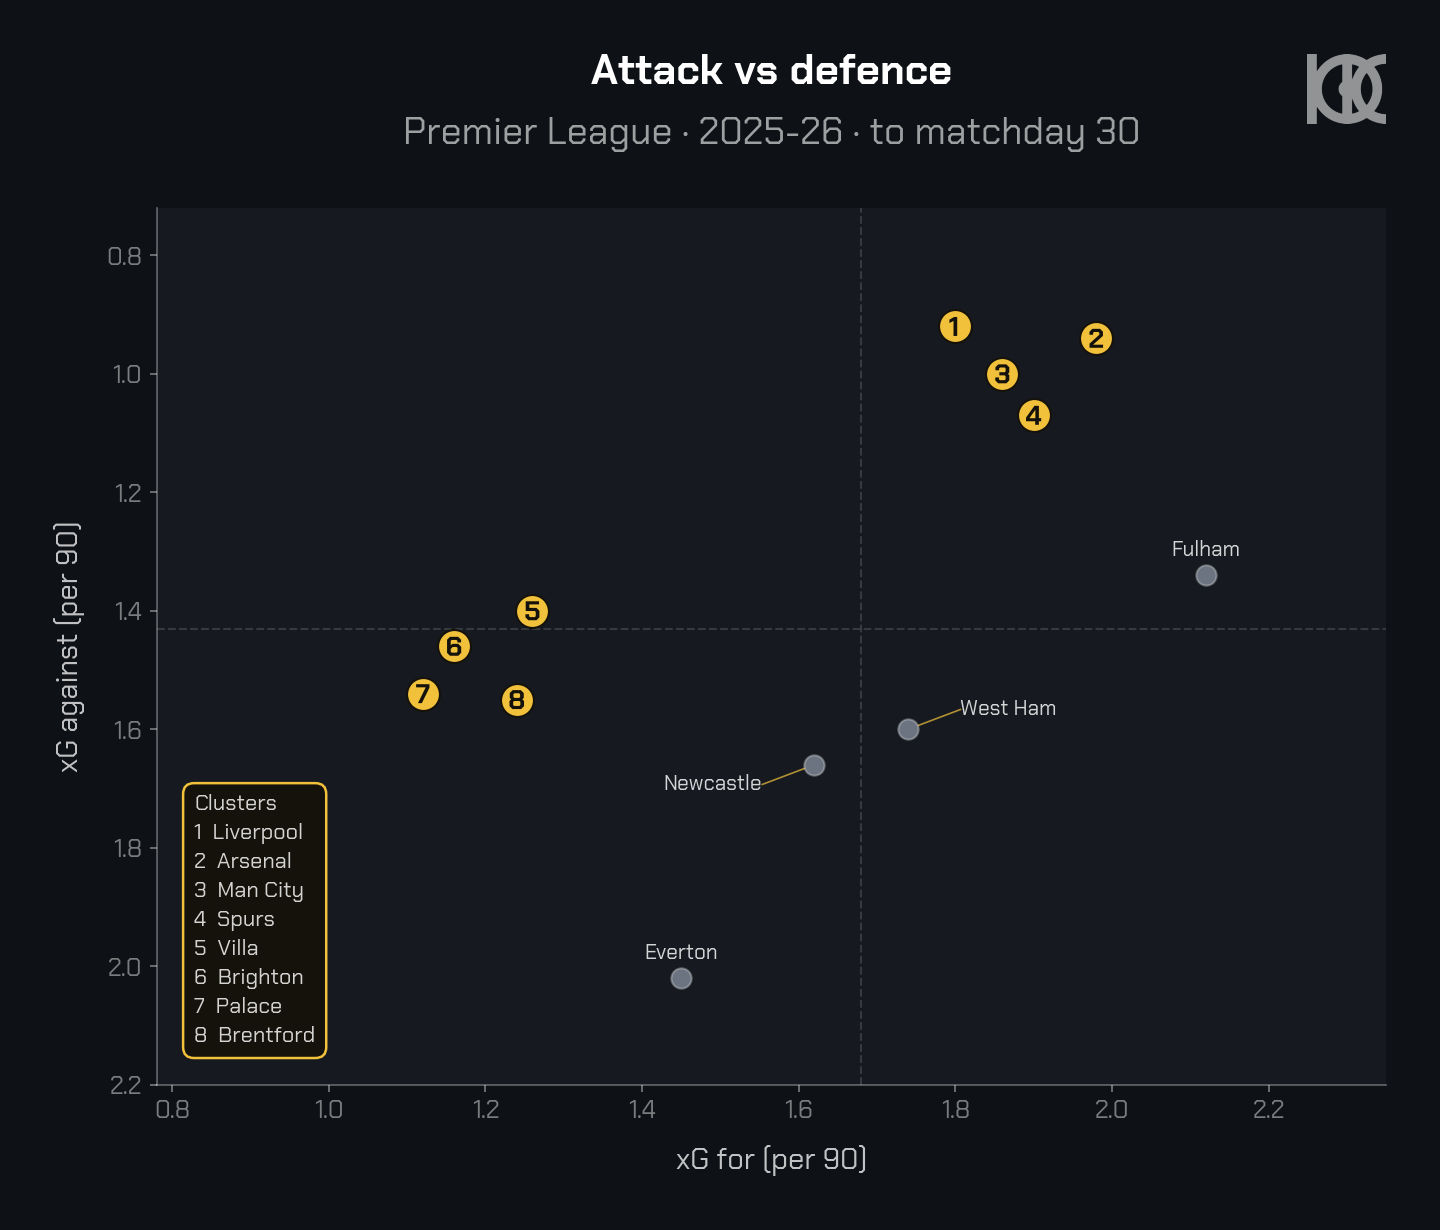

In [18]:
# a realistic mix — an elite cluster + a mid pack (both tight), a close pair, and isolated sides
xy = np.array([[1.86, 1.00], [1.98, 0.94], [1.80, 0.92], [1.90, 1.07],      # elite (tight 4)
               [1.16, 1.46], [1.26, 1.40], [1.12, 1.54], [1.24, 1.55],      # mid pack (tight 4)
               [1.62, 1.66], [1.74, 1.60],                                  # a close pair
               [2.12, 1.34], [1.45, 2.02]])                                 # isolated sides
labels = ["Man City", "Arsenal", "Liverpool", "Spurs", "Brighton", "Villa", "Palace", "Brentford",
          "Newcastle", "West Ham", "Fulham", "Everton"]
fig, ax = plt.subplots(figsize=(9.6, 8.2)); fig.set_facecolor(KICK["figure"]); ax.set_facecolor(KICK["panel"])
ax.axvline(np.median(xy[:, 0]), color=W(0.14), ls="--", lw=1, zorder=1)     # median crosshairs -> quadrants
ax.axhline(np.median(xy[:, 1]), color=W(0.14), ls="--", lw=1, zorder=1)
ax.scatter(xy[:, 0], xy[:, 1], s=95, c=KICK["muted"], edgecolor=W(0.30), linewidth=1.0, zorder=3)
ax.set_xlim(0.78, 2.35); ax.set_ylim(2.20, 0.72)             # invert y (fewer conceded = up); set BEFORE labelling
ax.set_xlabel("xG for (per 90)"); ax.set_ylabel("xG against (per 90)"); ax.grid(False)
# de-collide the clusters: tight -> numbered badges + key, small -> displaced labels, loners -> direct
kick_smart_labels(ax, xy, labels, eps=0.22, tight=4, key_loc="lower left", key_title="Clusters")
kick_title(fig, ax, "Attack vs defence", "Premier League · 2025-26 · to matchday 30", pitch=False)
kick_verify_margins(fig, label="§9 scatter")
plt.show()

## 10 · Momentum timeline — *two modes, stacked (non-pitch)*

The same signed momentum series drawn two ways and stacked to compare: **continuous** (a rolling fill
around the zero line — smooth, reads the flow of a match) and **discrete** (one bar per 3-minute window
— crisp, reads distinct spells). Both diverge home-vs-away around a muted baseline; the dotted line is
half-time. One shared header and one shared *Minute* axis via `kick_grid_header`.

[margins  OK ] §10 momentum stacked L=0.360 R=0.360 T=0.360 B=0.360


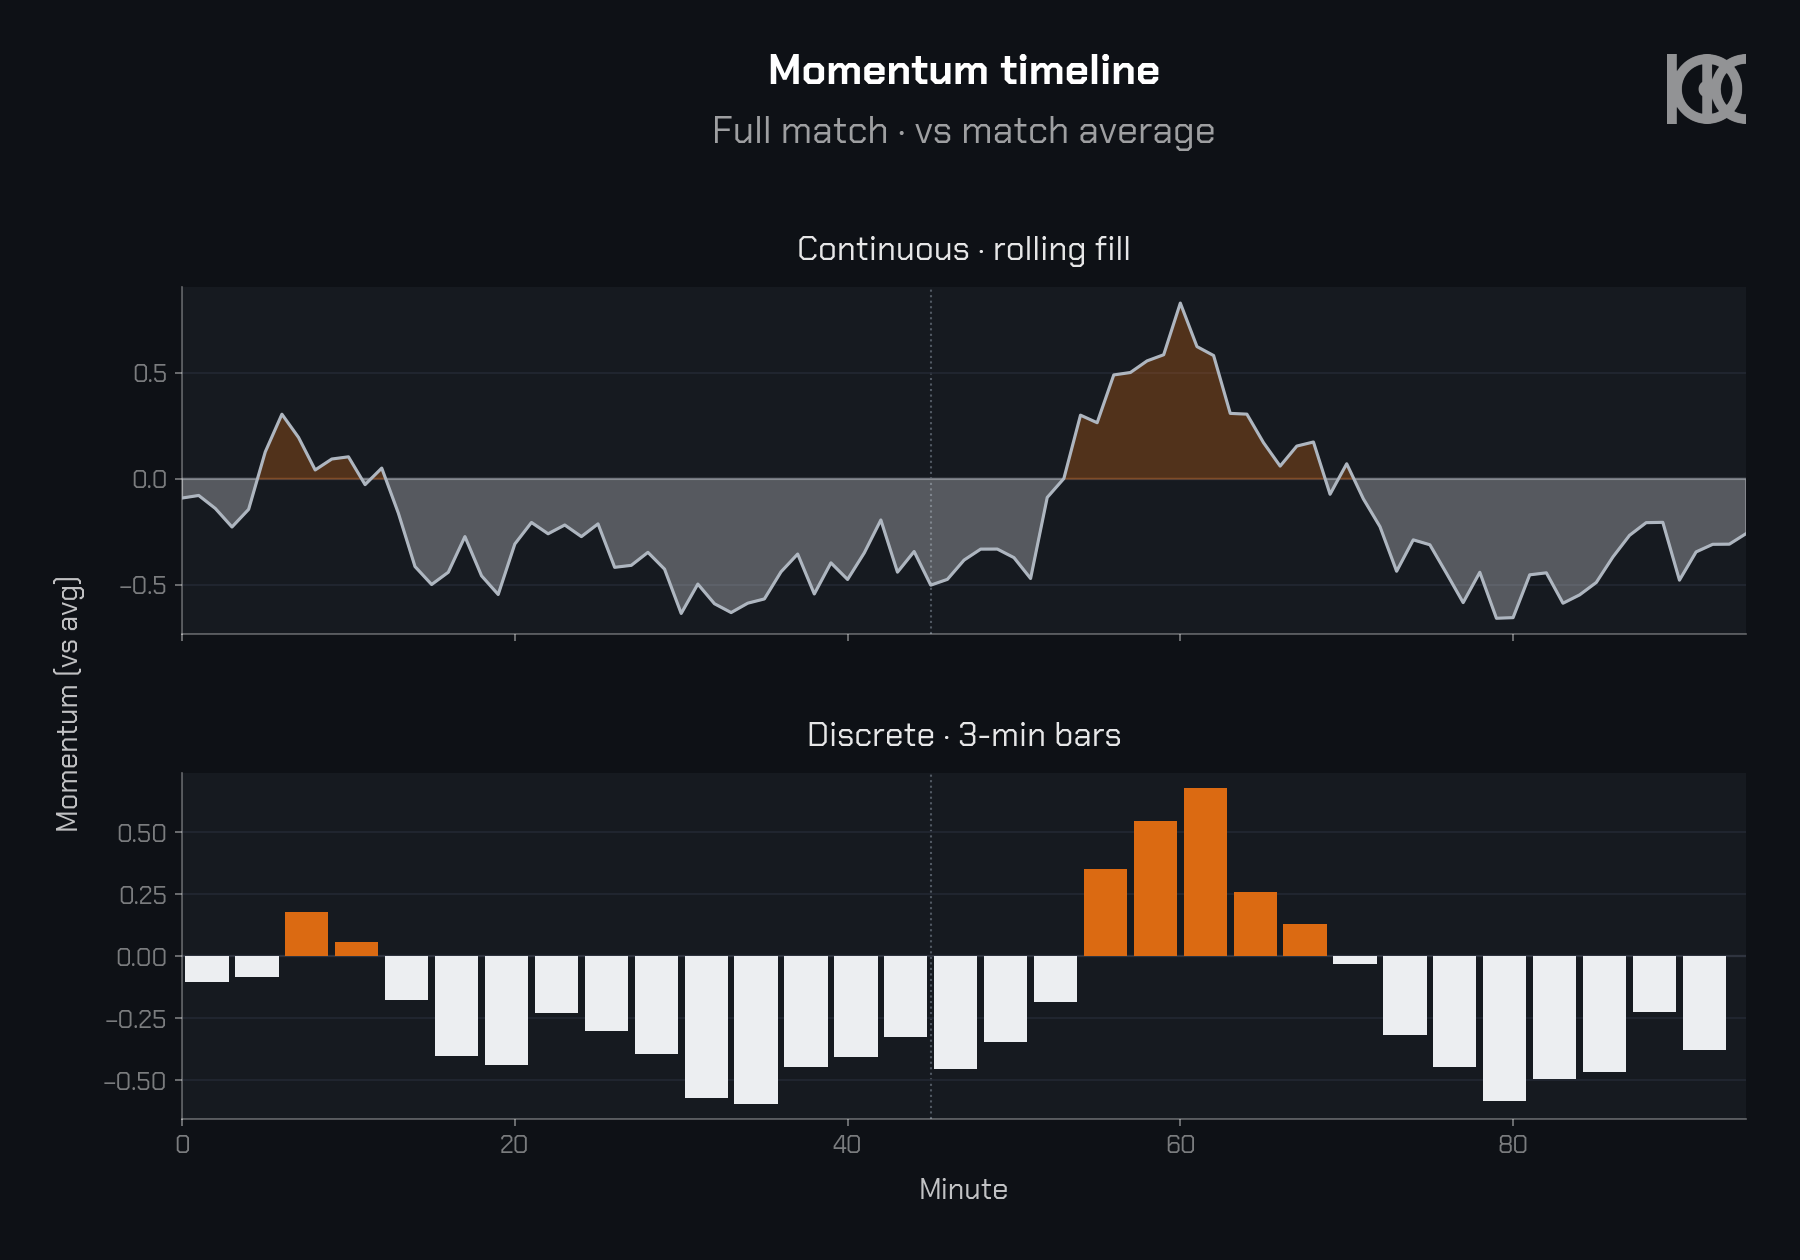

In [19]:
rng = np.random.default_rng(5)
t = np.arange(0, 95); mm = np.convolve(rng.normal(0, 1, len(t)), np.ones(9) / 9, mode="same")
fig, axes = plt.subplots(2, 1, figsize=(12, 8.4), squeeze=False); fig.set_facecolor(KICK["figure"])
ax1, ax2 = axes[0, 0], axes[1, 0]
# top — CONTINUOUS: rolling fill (the outline mode)
ax1.fill_between(t, mm, 0, where=mm >= 0, color=KICK["home"], alpha=0.30, interpolate=True, zorder=2)
ax1.fill_between(t, mm, 0, where=mm < 0, color=KICK["away"], alpha=0.30, interpolate=True, zorder=2)
ax1.plot(t, mm, color=KICK["ink_soft"], lw=1.5, zorder=3)
ax1.set_title("Continuous · rolling fill", color=W(0.90), fontsize=16, pad=13)
# bottom — DISCRETE: one bar per 3-minute window (the new mode)
edges = np.arange(0, 96, 3); ctr = (edges[:-1] + edges[1:]) / 2
binned = np.array([mm[(t >= lo) & (t < hi)].mean() for lo, hi in zip(edges[:-1], edges[1:])])
ax2.bar(ctr, binned, width=2.6, edgecolor="none", zorder=2,
        color=[KICK["home"] if v >= 0 else KICK["away"] for v in binned])
ax2.set_title("Discrete · 3-min bars", color=W(0.90), fontsize=16, pad=13)
for ax in (ax1, ax2):
    ax.axhline(0, color=KICK["muted"], lw=1, zorder=1); ax.set_xlim(0, 94)
    ax.axvline(45, color=KICK["muted"], ls=":", lw=1, alpha=0.7, zorder=1); ax.grid(axis="y")
ax1.tick_params(labelbottom=False)                           # shared x — only the bottom shows the minutes
kick_grid_header(fig, axes, "Momentum timeline", "Full match · vs match average",
                 xlabel="Minute", ylabel="Momentum (vs avg)", hspace=0.40)
kick_verify_margins(fig, label="§10 momentum stacked")
plt.show()

## 11 · Small multiples — *comparison grids*

`kick_grid(nrows, ncols)` returns styled pitch panels for side-by-side comparison (teams, halves,
phases, players). One overall header + logo via `kick_grid_title`, a per-panel label via
`kick_panel_label`, and one shared colourbar via `kick_grid_cbar` — everything on a common scale. The
bar sits **below the grid** (horizontal, label underneath — `cbar=True, cbar_pos="bottom"`), matching the
single-pitch surface; `cbar_pos="right"` puts it in a slim right gutter instead.

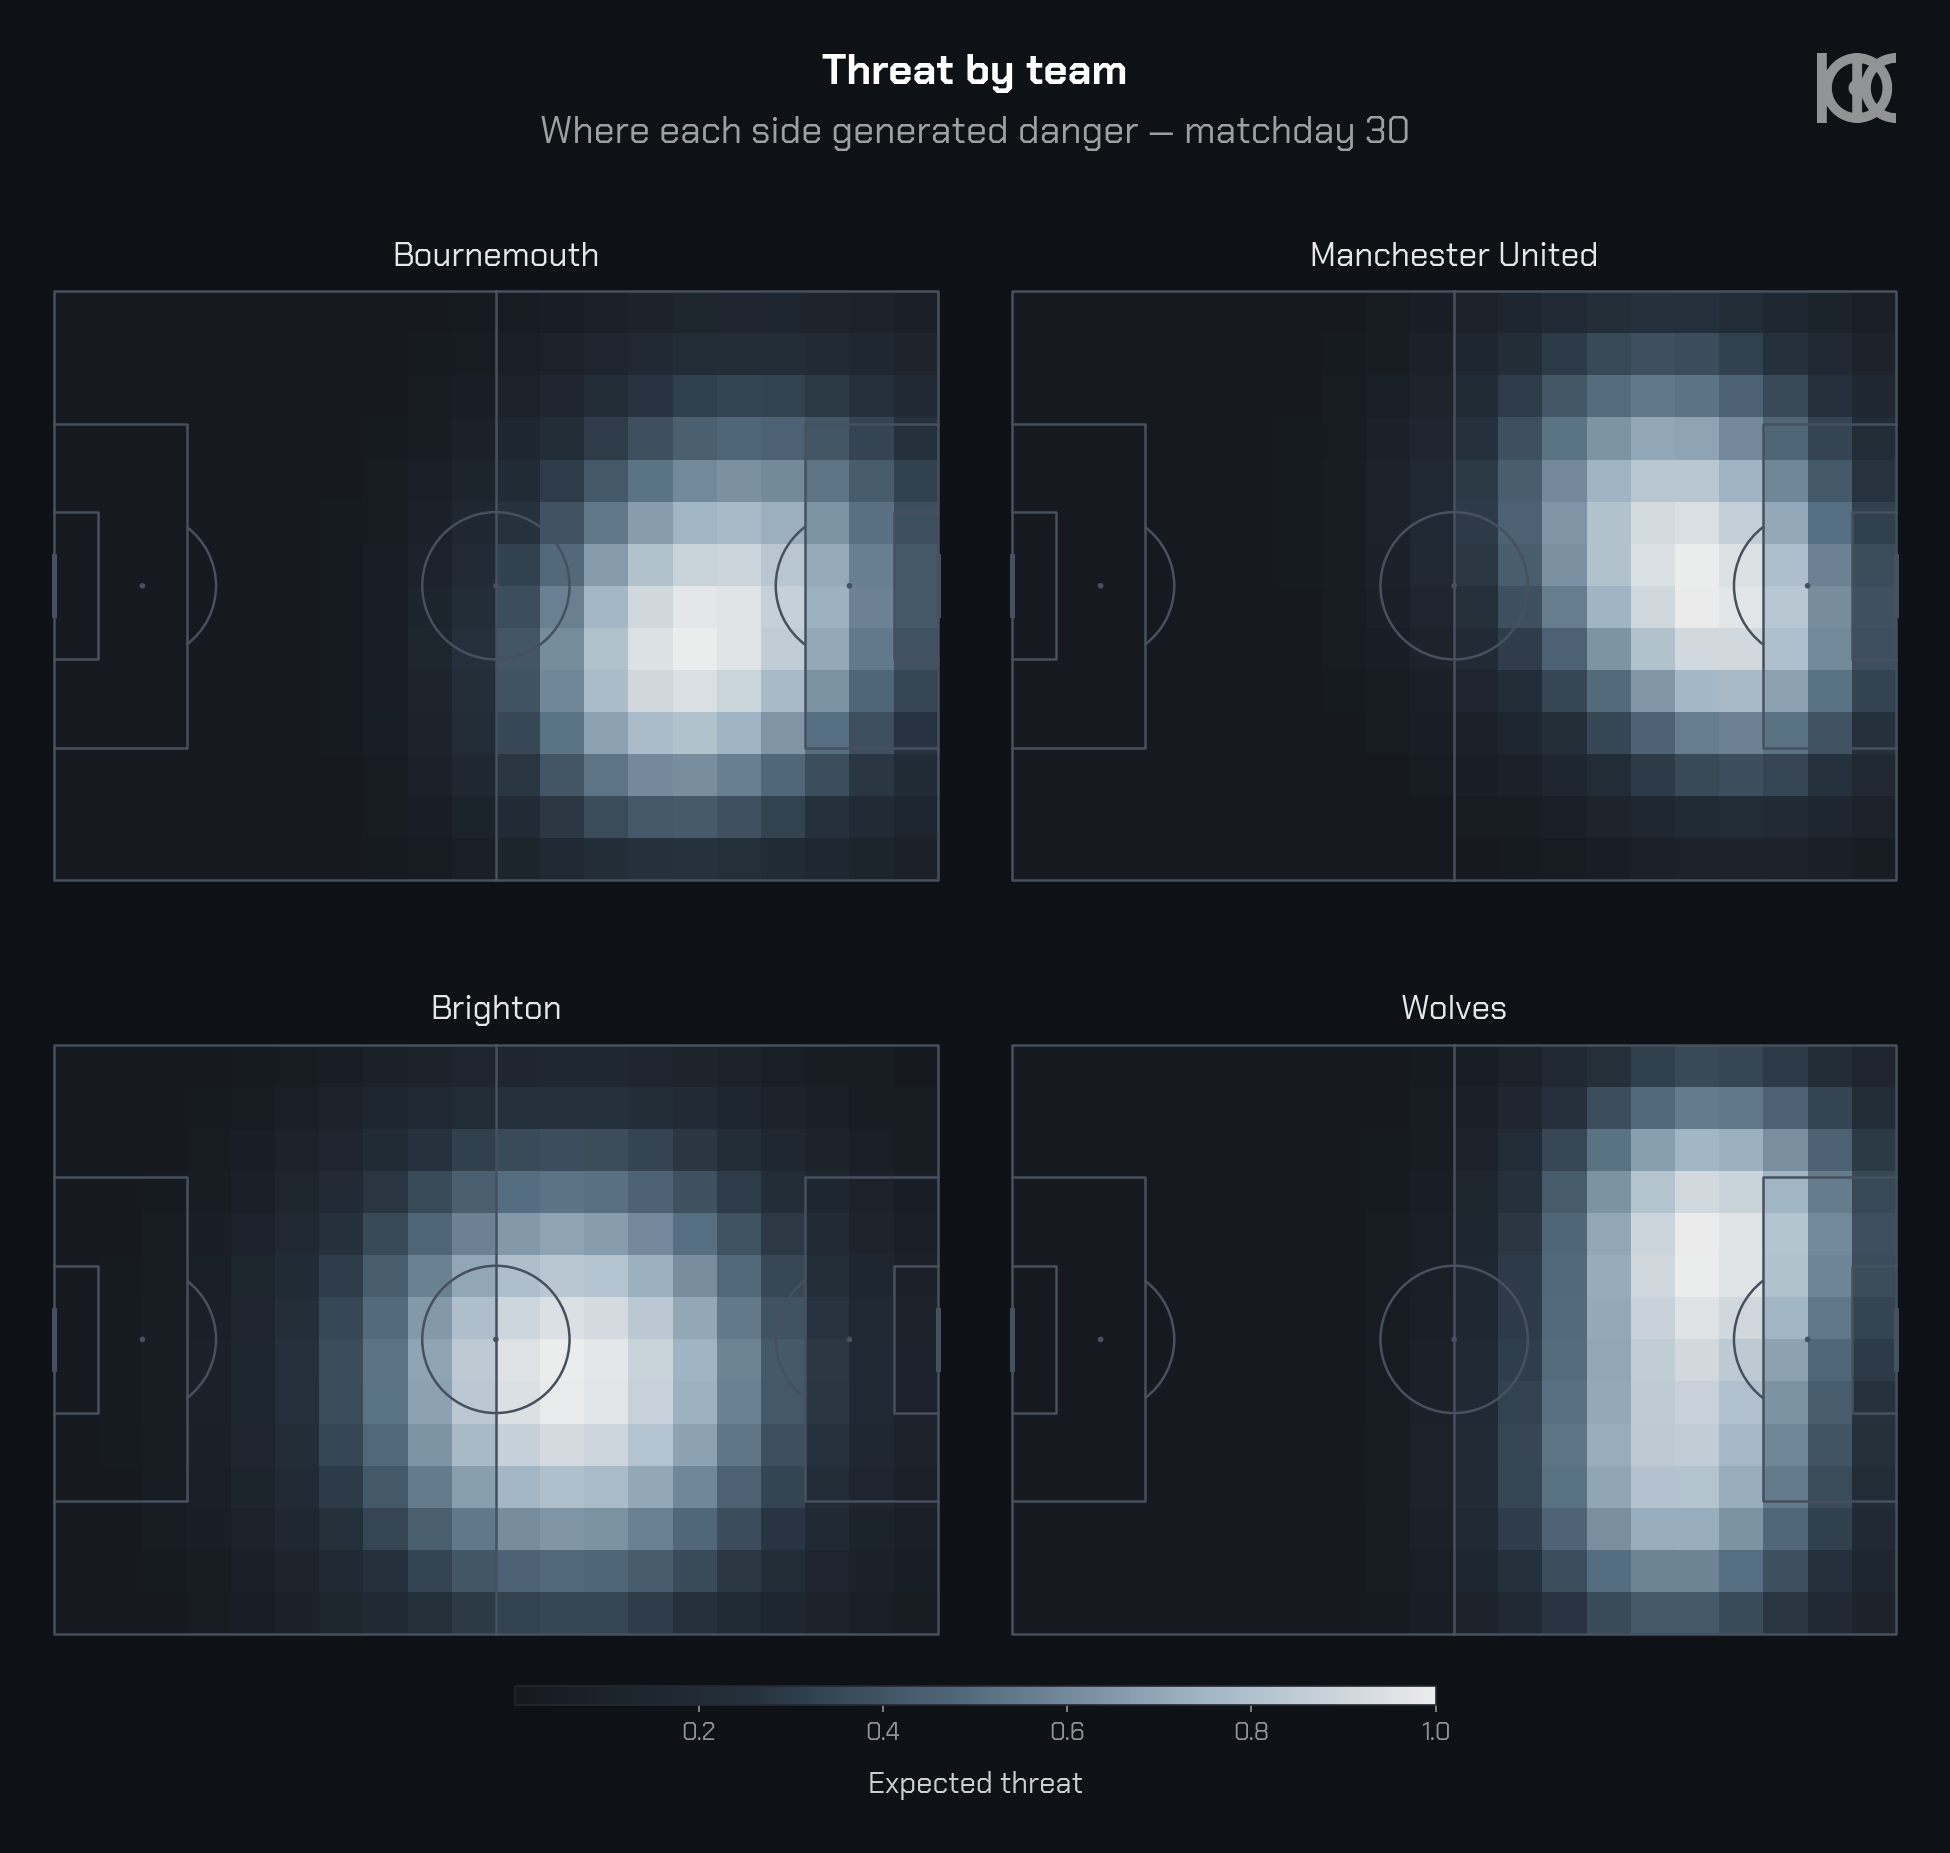

In [20]:
nx2, ny2 = 20, 14
xe2 = np.linspace(0, 120, nx2 + 1); ye2 = np.linspace(0, 80, ny2 + 1)
xc2 = (xe2[:-1] + xe2[1:]) / 2; yc2 = (ye2[:-1] + ye2[1:]) / 2
gx2, gy2 = np.meshgrid(xc2, yc2)
panels = [("Bournemouth", [(95, 40, 20, 1.0), (80, 55, 15, .6)]),
          ("Manchester United", [(88, 30, 18, 1.0), (100, 50, 14, .7)]),
          ("Brighton", [(70, 45, 22, 1.0)]),
          ("Wolves", [(95, 25, 16, 1.0), (90, 60, 16, .8)])]

pitch, fig, axes = kick_grid(2, 2, cbar=True, cbar_pos="bottom")   # shared bar BELOW the grid (label underneath)
m = None
for ax, (lab, sp) in zip(axes.flat, panels):
    m = kick_heatmap(ax, xe2, ye2, blob(gx2, gy2, sp))
    kick_panel_label(ax, lab)
kick_grid_cbar(fig, axes, m, "Expected threat")
kick_grid_title(fig, axes, "Threat by team", "Where each side generated danger — matchday 30")
plt.show()

## 12 · Reference — tokens & ramps

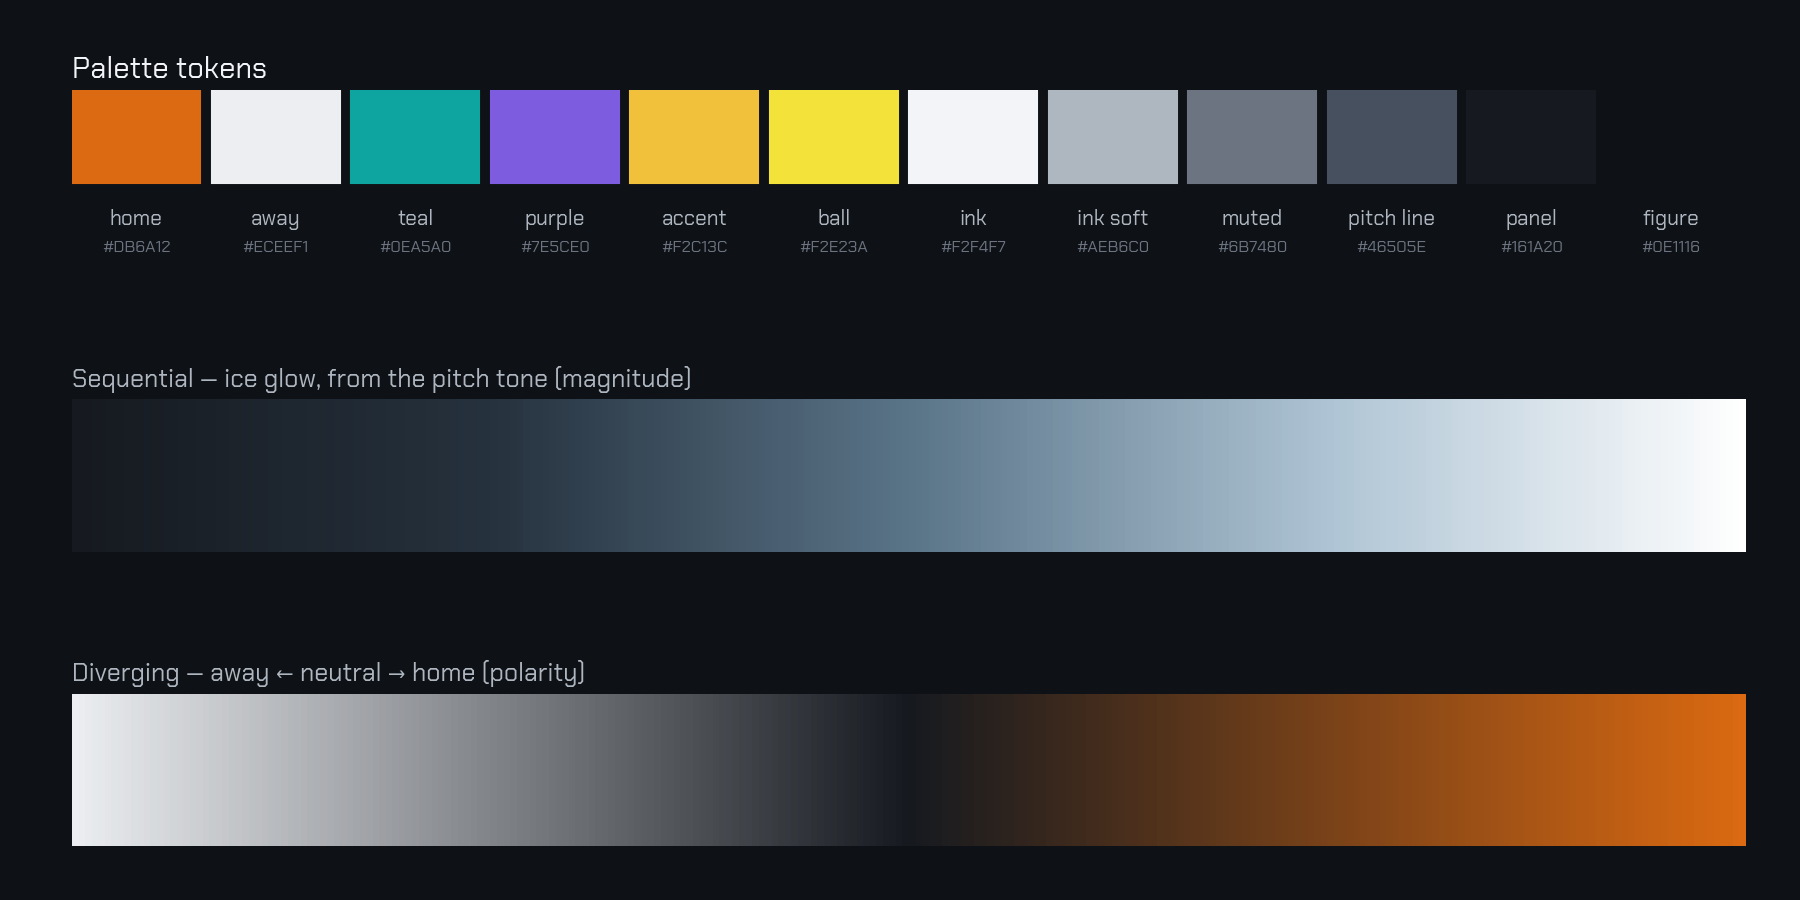

In [21]:
fig = plt.figure(figsize=(12, 6), facecolor=KICK["figure"])
fig.subplots_adjust(top=0.9, bottom=0.06, left=0.04, right=0.97)
gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1, 1], hspace=0.9)
ax0 = fig.add_subplot(gs[0]); ax0.set_facecolor(KICK["figure"]); ax0.axis("off")
# the colours actually used: teams + the two categorical extras + the highlight + ball, then structural tones
cats = [("home", "home"), ("away", "away"), ("teal", "teal"), ("purple", "purple"), ("accent", "accent"),
        ("ball", "ball"), ("ink", "ink"), ("ink_soft", "ink soft"), ("muted", "muted"),
        ("pitch_line", "pitch line"), ("panel", "panel"), ("figure", "figure")]
for i, (k, lab) in enumerate(cats):
    ax0.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=KICK[k]))
    ax0.text(i + 0.46, -0.28, lab, ha="center", va="top", color=KICK["ink_soft"], fontsize=10)
    ax0.text(i + 0.46, -0.62, KICK[k], ha="center", va="top", color=KICK["muted"], fontsize=8)
ax0.set_xlim(0, len(cats)); ax0.set_ylim(-0.8, 1); ax0.set_title("Palette tokens", color=KICK["ink"], fontsize=14, loc="left")
grad = np.linspace(0, 1, 256).reshape(1, -1)
for row, (cmap, name) in [(1, (KICK_SEQ, "Sequential — ice glow, from the pitch tone (magnitude)")),
                          (2, (KICK_DIV, "Diverging — away ← neutral → home (polarity)"))]:
    ax = fig.add_subplot(gs[row]); ax.imshow(grad, aspect="auto", cmap=cmap); ax.set_yticks([]); ax.set_xticks([])
    ax.set_title(name, color=KICK["ink_soft"], fontsize=12, loc="left", pad=6)
    for sp in ax.spines.values(): sp.set_visible(False)
plt.show()